# Imports

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
plt.style.use("default")
%config InlineBackend.figure_format = 'retina'


# Parameters

In [ ]:
paths_to_extracted_spectra = {
    "westham_center": Path(
        "/home/coder/wesa-fup-restricted/radiometetry_eval/micasense_westham_center_extracted_spectra.geojson"
    ),
    "westham_north": Path(
        "/home/coder/wesa-fup-restricted/radiometetry_eval/micasense_westham_north_extracted_spectra.geojson"
    ),
    "brunswick": Path(
        "/home/coder/wesa-fup-restricted/radiometetry_eval/micasense_brunswick_extracted_spectra.geojson"
    ),
}

path_to_resampled_spectrometer_spectra = Path(
    "/home/coder/wesa-fup-restricted/data_test/processed/spectra/runs/2026-07-17T162053Z__git47ecadc__cfg5319719d/outputs/panels_mean_
    d_spectra.parquet"
    # "/home/coder/wesa-fup-restricted/data_test/processed/spectra/latest/outputs/panels_mean_resampled_spectra.parquet"
)
path_to_badly_calibrated_resampled_spectrometer_spectra = Path(
    "/home/coder/wesa-fup-restricted/data_test/processed/spectra/runs/2026-07-21T160319Z__git293256c__cfg5319719d/outputs/panels_mean_resampled_spectra.parquet"
)

path_to_before_after_panel_extracted_spectra = Path(
    "/home/coder/wesa-fup-restricted/radiometetry_eval/micasense_tarps_extracted_spectra_before_after_during_round_2.geojson"
)

MICASENSE_CENTER_WAVELENGTHS = np.array(
    [444, 475, 531, 560, 650, 668, 705, 717, 740, 842]
)

# Read GeoJSON files

In [4]:
# read geojson file with geopandas
gdfs_extracted_spectra = {}
for key, path in paths_to_extracted_spectra.items():
    gdf = gpd.read_file(path).rename(columns={"Day": "day", "Descrip": "description"})
    gdfs_extracted_spectra[key] = gdf

/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


In [5]:
dfs_spectra = {}

for key, gdf in gdfs_extracted_spectra.items():

    # Create a dataframe with the following index: MICASENSE_CENTER_WAVELENGTHS, and the following MultiIndex colunms: day, id, description
    df_spectra = pd.DataFrame(
        index=MICASENSE_CENTER_WAVELENGTHS,
        columns=pd.MultiIndex.from_product(
            [[4, 18], gdf["id"].unique(), ['mean', 'std']],
        ),
    )
    # # Add the description as a third level of the MultiIndex columns without product
    # df_spectra.columns = pd.MultiIndex.from_tuples(
    #     [
    #         (day, id, gdf[gdf["id"] == id]["description"].values[0])
    #         for day, id in df_spectra.columns
    #     ]
    # )

    # Make sure data are floats
    df_spectra = df_spectra.astype(float)

    # Loop over the rows of the gdf and fill the df_spectra with the spectra values
    for index, row in gdf.iterrows():
        day = row["day"]
        id = row["id"]
        description = row["description"]
        # If day is NaN, spectra should be retrieved for both days
        if pd.isna(day):
            for day in [4, 18]:
                # Retrieve all columns starting with f'may{day}'
                mean_columns = [col for col in gdf.columns if col.startswith(f"may{day}") and col.endswith("mean")]
                std_columns = [col for col in gdf.columns if col.startswith(f"may{day}") and col.endswith("stdev")]
                mean_spectrum = row[mean_columns].astype(float)
                mean_spectrum.index = MICASENSE_CENTER_WAVELENGTHS
                df_spectra.loc[:, (day, id, 'mean')] = mean_spectrum
                std_spectrum = row[std_columns].astype(float)
                std_spectrum.index = MICASENSE_CENTER_WAVELENGTHS
                df_spectra.loc[:, (day, id, "std")] = std_spectrum
        else:
            # Retrieve all columns starting with f'may{day}'
            day = int(day)
            mean_columns = [col for col in gdf.columns if col.startswith(f"may{day}") and col.endswith("mean")]
            mean_spectrum = row[mean_columns].astype(float)
            mean_spectrum.index = MICASENSE_CENTER_WAVELENGTHS
            df_spectra.loc[:, (day, id, 'mean')] = mean_spectrum
            std_columns = [col for col in gdf.columns if col.startswith(f"may{day}") and col.endswith("stdev")]
            std_spectrum = row[std_columns].astype(float)
            std_spectrum.index = MICASENSE_CENTER_WAVELENGTHS
            df_spectra.loc[:, (day, id, 'std')] = std_spectrum

    # Drop columns with all NaN values
    df_spectra = df_spectra.dropna(axis=1, how="all")
    df_spectra

    dfs_spectra[key] = df_spectra

In [6]:
# for key, gdf in gdfs_extracted_spectra.items():

#     # Create a figure with as many subplots as unique ids
#     fig, axs = plt.subplots(gdf["id"].nunique(), 1, figsize=(10, 6 * gdf["id"].nunique()), sharex=True)
#     for iid, id in enumerate(gdf["id"].unique()):
#         ax = axs[iid]
#         for day in [4, 18]:
#             if (day, id, 'mean') in df_spectra.columns:
#                 mean_spectrum = df_spectra.loc[:, (day, id, 'mean')]
#                 std_spectrum = df_spectra.loc[:, (day, id, 'std')]
#                 ax.plot(
#                     MICASENSE_CENTER_WAVELENGTHS,
#                     mean_spectrum,
#                     'o-',
#                     label=f"Day {day}",
#                 )
#                 ax.fill_between(
#                     MICASENSE_CENTER_WAVELENGTHS,
#                     mean_spectrum - std_spectrum,
#                     mean_spectrum + std_spectrum,
#                     alpha=0.2,
#                 )
#         ax.set_title(f"Spectra for ID {id}: {gdf[gdf['id'] == id]['description'].values[0].title()}")
#         ax.set_xlabel("Wavelength (nm)")
#         ax.set_ylabel("Reflectance")
#         ax.legend()
#     plt.show()



(0.0, 0.7214698749966919)

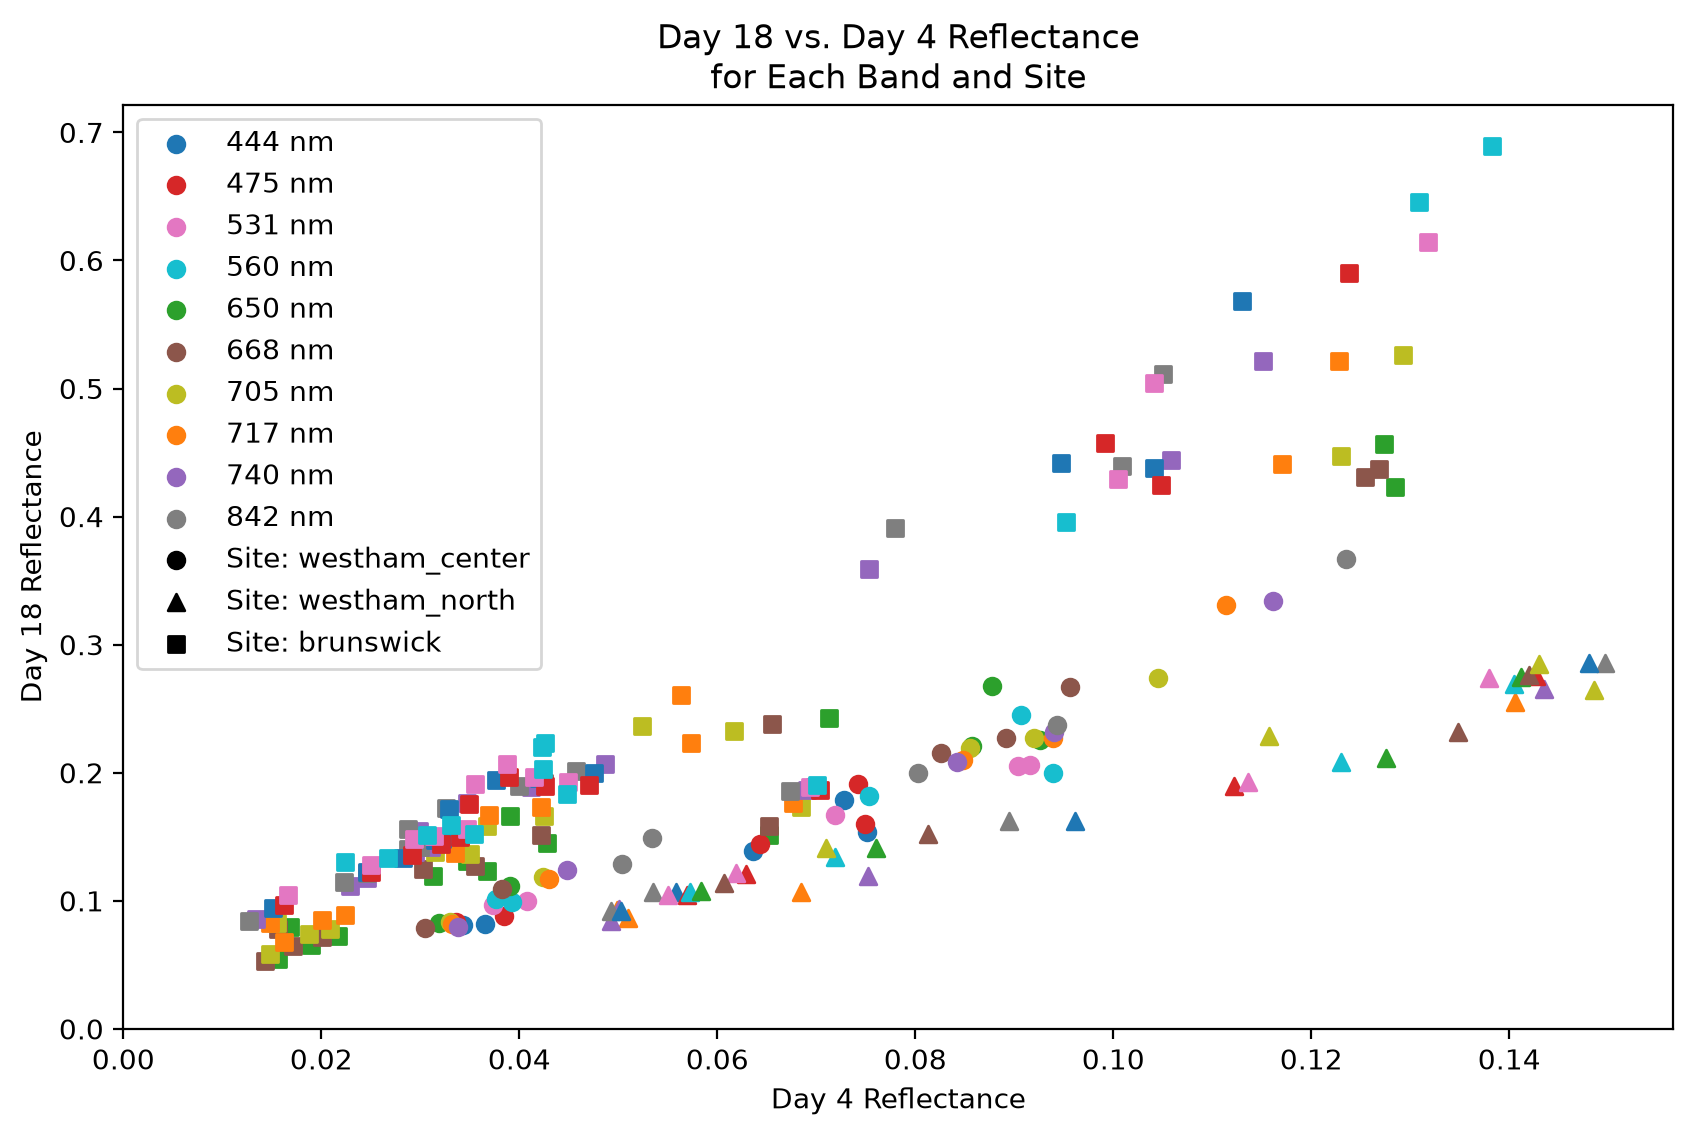

In [7]:
dfs_band_mean = {}

for key, df_spectra in dfs_spectra.items():

    df_band_mean = df_spectra.xs('mean', level=2, axis=1)
    # Remove ids not present in both days
    for id in df_band_mean.columns.get_level_values(1).unique():
        if not all([(day, id) in df_band_mean.columns for day in [4, 18]]):
            df_band_mean = df_band_mean.drop(columns=[(day, id) for day in [4, 18] if (day, id) in df_band_mean.columns])

    dfs_band_mean[key] = df_band_mean

    # # Scatter plot of day 18 vs. day 4 for each row (=band), all ids together
    # fig, ax = plt.subplots(figsize=(10, 6))
    # for band in df_band_mean.index:
    #     ax.scatter(
    #         df_band_mean.loc[band, 4],
    #         df_band_mean.loc[band, 18],
    #         label=f"{band} nm",
    #     )
    # ax.set_xlabel("Day 4 Reflectance")
    # ax.set_ylabel("Day 18 Reflectance")
    # ax.set_title("Day 18 vs. Day 4 Reflectance for Each Band")
    # ax.legend()
    # ax.set_xlim(left=0)
    # ax.set_ylim(bottom=0)

# Scatter plot of all areas with a different marker and a color for each band
fig, ax = plt.subplots(figsize=(10, 6))
markers = {'westham_center': 'o', 'westham_north': '^', 'brunswick': 's'}
bands = dfs_band_mean['westham_center'].index  # Assuming all dfs have the same bands
for band in bands:
    legend_plotted = False
    for key, df_band_mean in dfs_band_mean.items():
        if not legend_plotted:
            label = f"{band} nm"
            legend_plotted = True
        else:
            label = None
        ax.scatter(
            df_band_mean.loc[band, 4],
            df_band_mean.loc[band, 18],
            marker = markers[key],
            label=label,
        )

ax.set_xlabel("Day 4 Reflectance")
ax.set_ylabel("Day 18 Reflectance")
ax.set_title("Day 18 vs. Day 4 Reflectance\nfor Each Band and Site")
# Add different markers per site on the legend
for marker in markers.values():
    ax.scatter([], [], marker=marker, label=f"Site: {list(markers.keys())[list(markers.values()).index(marker)]}", color='k')
ax.legend()
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)


In [8]:
dict_object_id_list_per_site_and_type = {}

for key, gdf_extracted_spectra in gdfs_extracted_spectra.items():
    print(f"{key}:\n{gdf_extracted_spectra.description}")

    dict_types = {
        "panel": gdf_extracted_spectra[gdf_extracted_spectra["description"].str.contains("panel", case=False, na=False)]["id"].unique().tolist(),
        "roof": gdf_extracted_spectra[gdf_extracted_spectra["description"].str.contains("roof", case=False, na=False)]["id"].unique().tolist(),
        "road": gdf_extracted_spectra[gdf_extracted_spectra["description"].str.contains("road", case=False, na=False)]["id"].unique().tolist(),
        "other": gdf_extracted_spectra[~gdf_extracted_spectra["description"].str.contains("panel|roof|road", case=False, na=False)]["id"].unique().tolist(),
    }
    dict_object_id_list_per_site_and_type[key] = dict_types



westham_center:
0     grey panel
1     grey panel
2    black panel
3      grey roof
4      grey roof
5      grey roof
6      grey roof
Name: description, dtype: str
westham_north:
0       brown box roof
1    large gravel area
2    greysunlight roof
3            dirt path
Name: description, dtype: str
brunswick:
0     Brown thing on construction site
1     Brown thing on construction site
2                            Road dark
3                          Road bright
4                            Grey roof
5                    Red brownish roof
6                    Unoccupied ground
7                       Big roof North
8                       Big roof South
9                         Blueish roof
10                        Yellow thing
11                        Yellow thing
12                            Red roof
13                          White roof
14                       Road brighter
Name: description, dtype: str


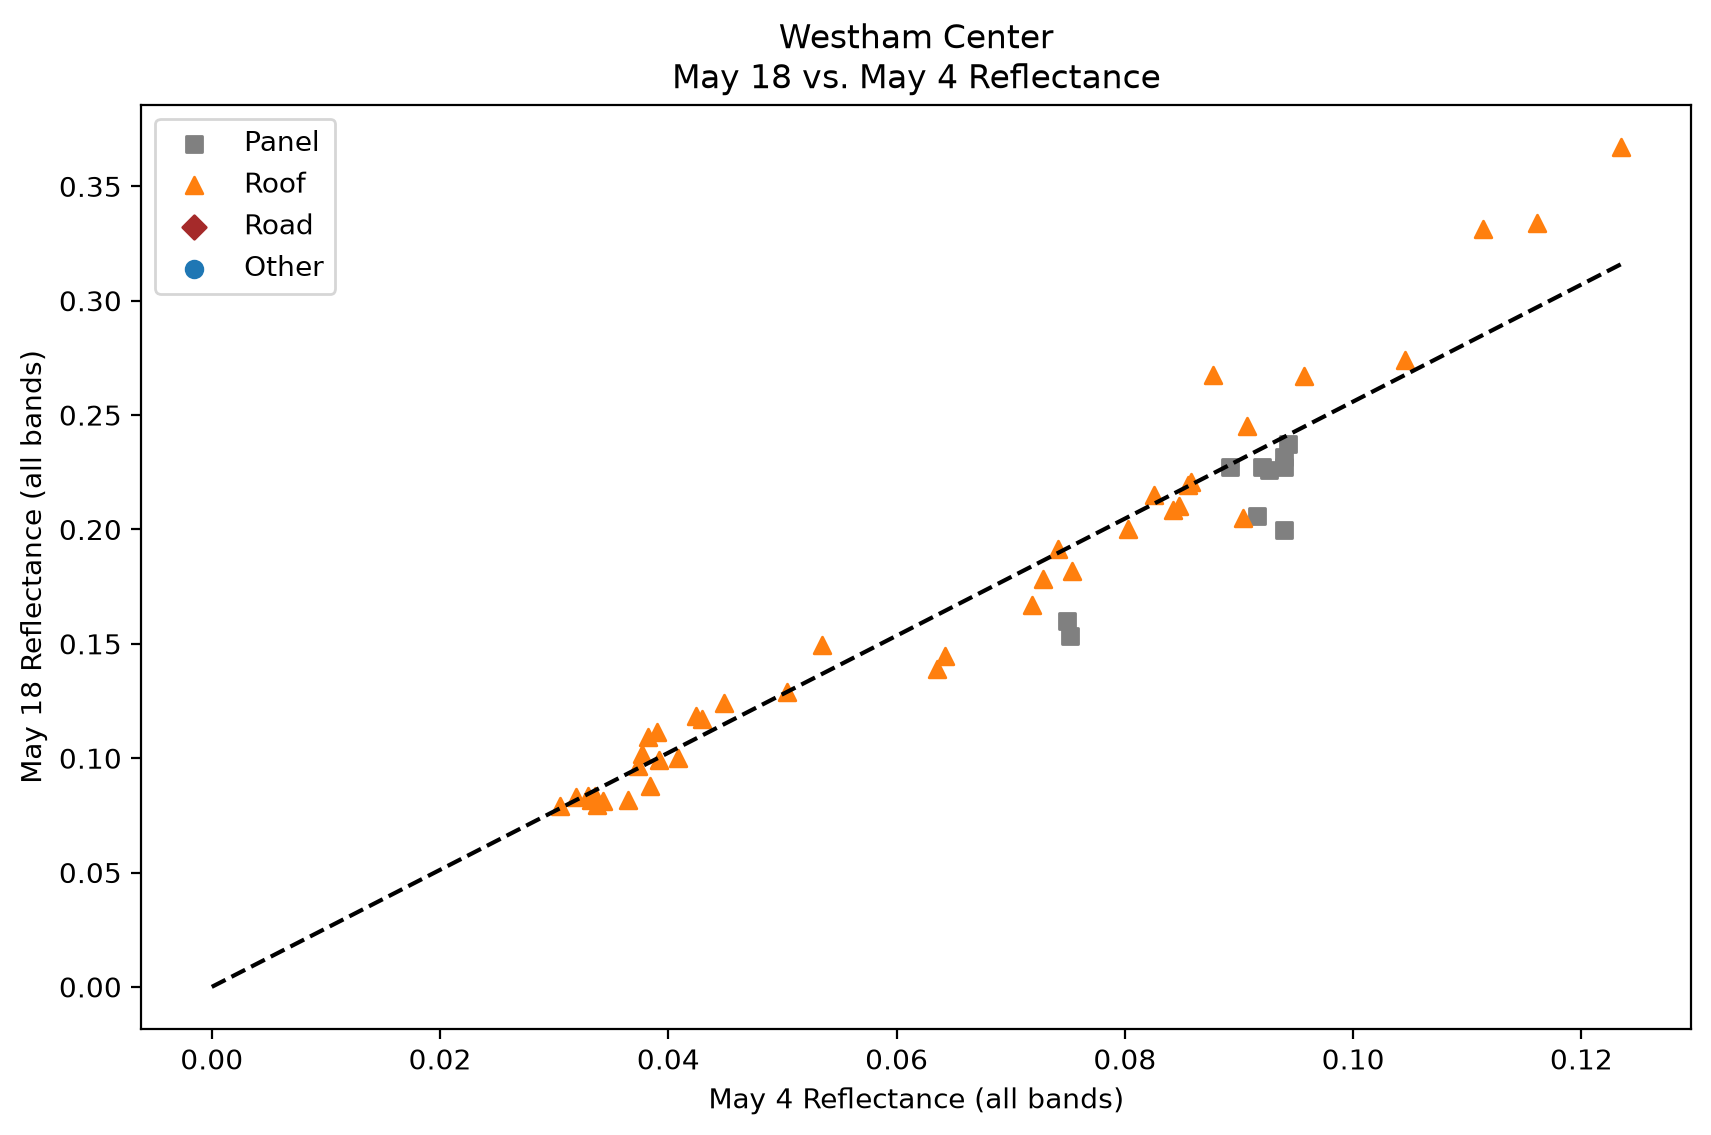

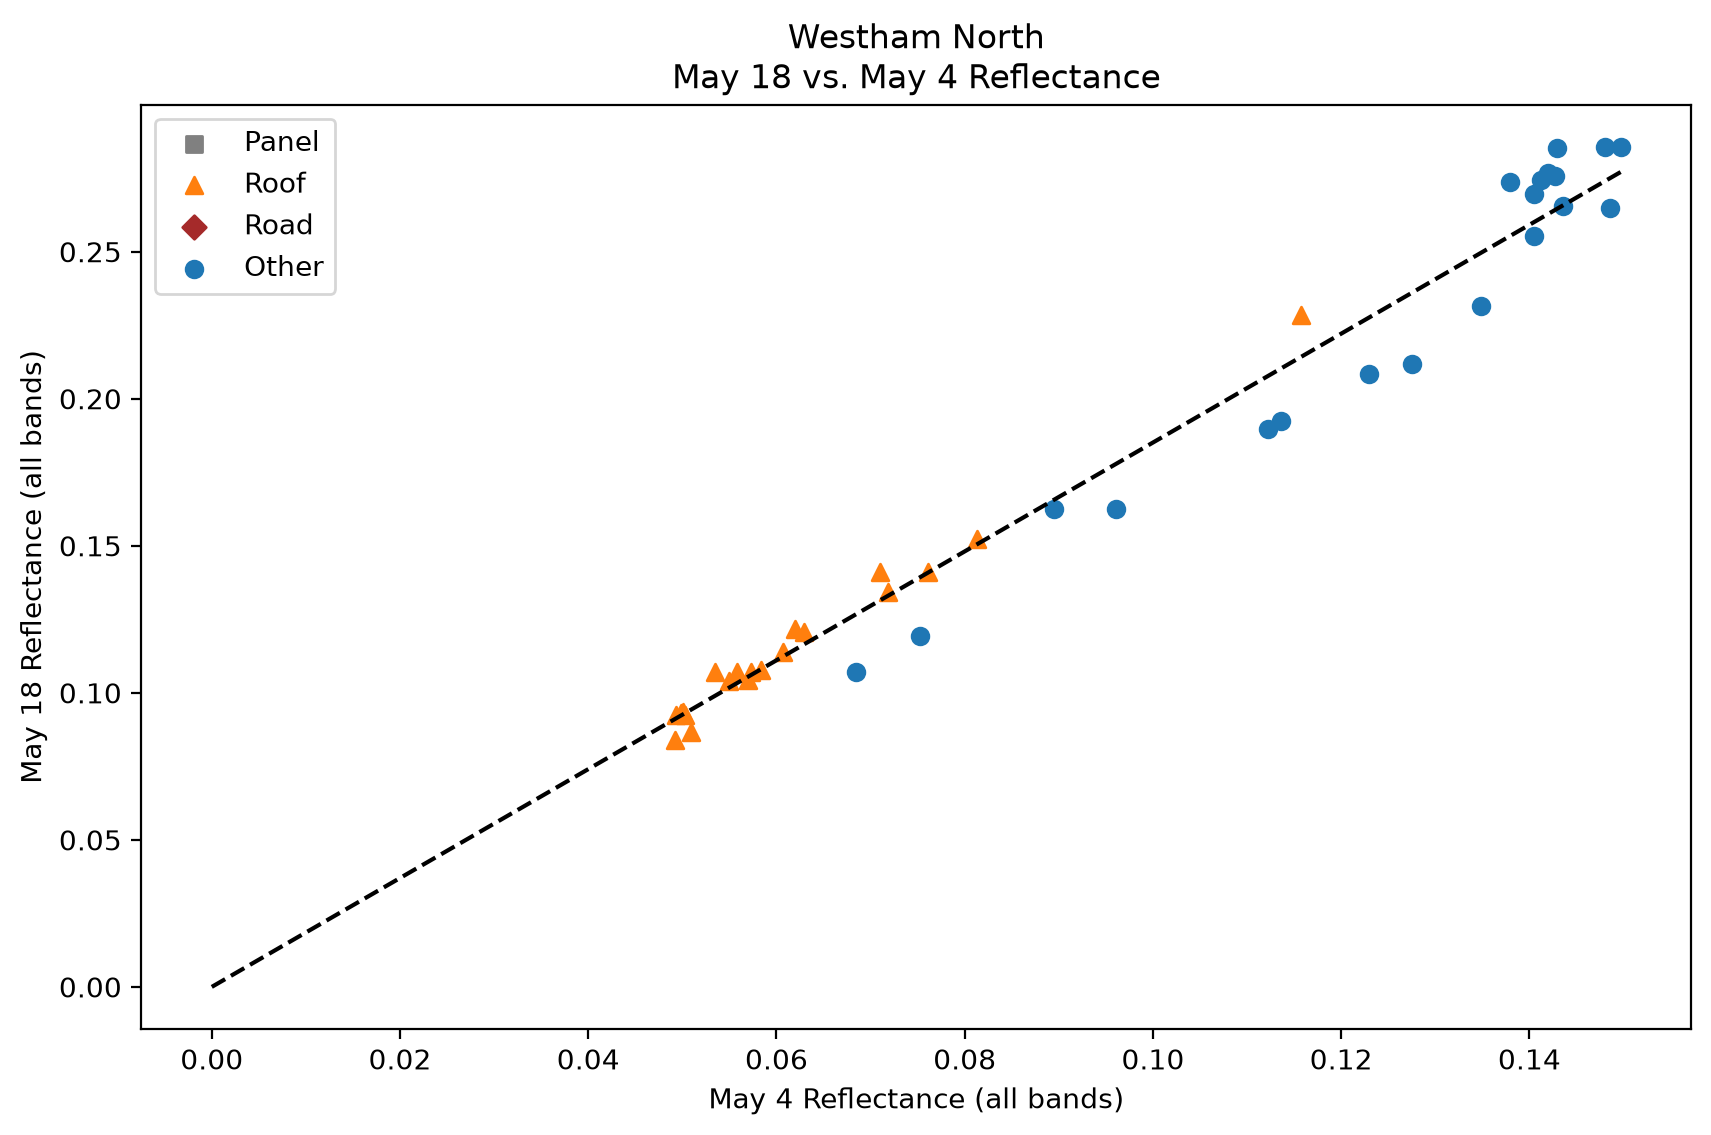

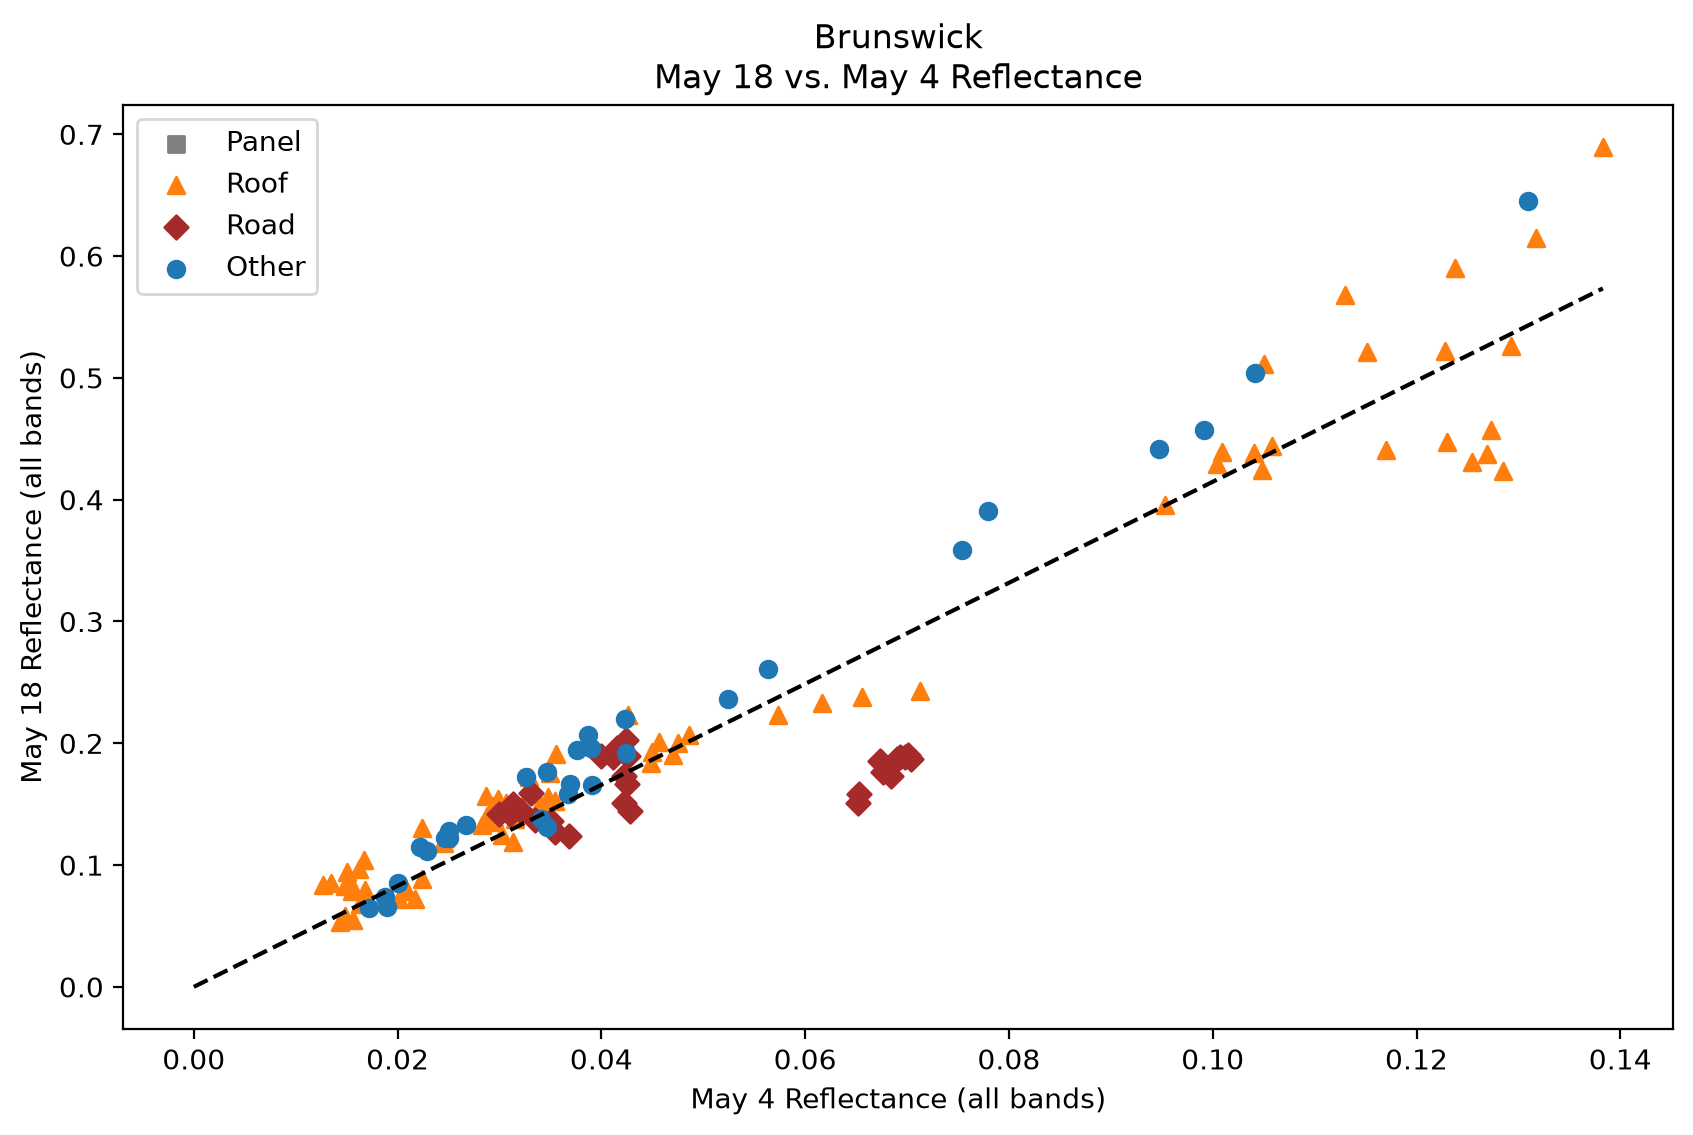

In [9]:
# Loop over areas but consider all bands at once, and fit a slope (linear regression with intercept=0) for the relation between day 18 (y) and day 4 (x) reflectance, and plot the slope for each area
fit_intercept = False
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
object_type_colors = {
    "panel": "grey",
    "roof": "tab:orange",
    "road": "brown",
    "other": "tab:blue",
}
object_type_markers = {
    "panel": "s",
    "roof": "^",
    "road": "D",
    "other": "o",
}
for ikey, (key, df_band_mean) in enumerate(dfs_band_mean.items()):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = df_band_mean.xs(4, level=0, axis=1).values.reshape(-1, 1)
    y = df_band_mean.xs(18, level=0, axis=1).values.reshape(-1, 1)
    # Fit linear regression with intercept=0
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(x, y)
    slope = model.coef_[0][0]
    if fit_intercept:
        intercept = model.intercept_[0]
        print(
            f"{key}: slope = {slope:.3f}, intercept = {intercept:.3e} (%mean = {100 * intercept / np.mean(y):.1f})"
        )
    # Scatter plot with fit, using same color
    for itype, type_ in enumerate(dict_object_id_list_per_site_and_type[key].keys()):
        ids = dict_object_id_list_per_site_and_type[key][type_]
        valid_ids = [id for id in ids if (4, id) in df_band_mean.columns and (18, id) in df_band_mean.columns]
        x_type = df_band_mean.xs(4, level=0, axis=1)[valid_ids].values.reshape(-1, 1)
        y_type = df_band_mean.xs(18, level=0, axis=1)[valid_ids].values.reshape(-1, 1)
        ax.scatter(
            x_type,
            y_type,
            label=f"{type_.title()}",
            color=object_type_colors[type_],#colors[itype],
            marker=object_type_markers[type_],
        )
    ax.plot(
        [0, x.max()], model.predict([[0], [x.max()]]), color='k',
        ls='--',
    )
    ax.set_xlabel("May 4 Reflectance (all bands)")
    ax.set_ylabel("May 18 Reflectance (all bands)")
    ax.set_title(
        f"{key.replace('_', ' ').title()}\nMay 18 vs. May 4 Reflectance"
    )

    ax.legend()


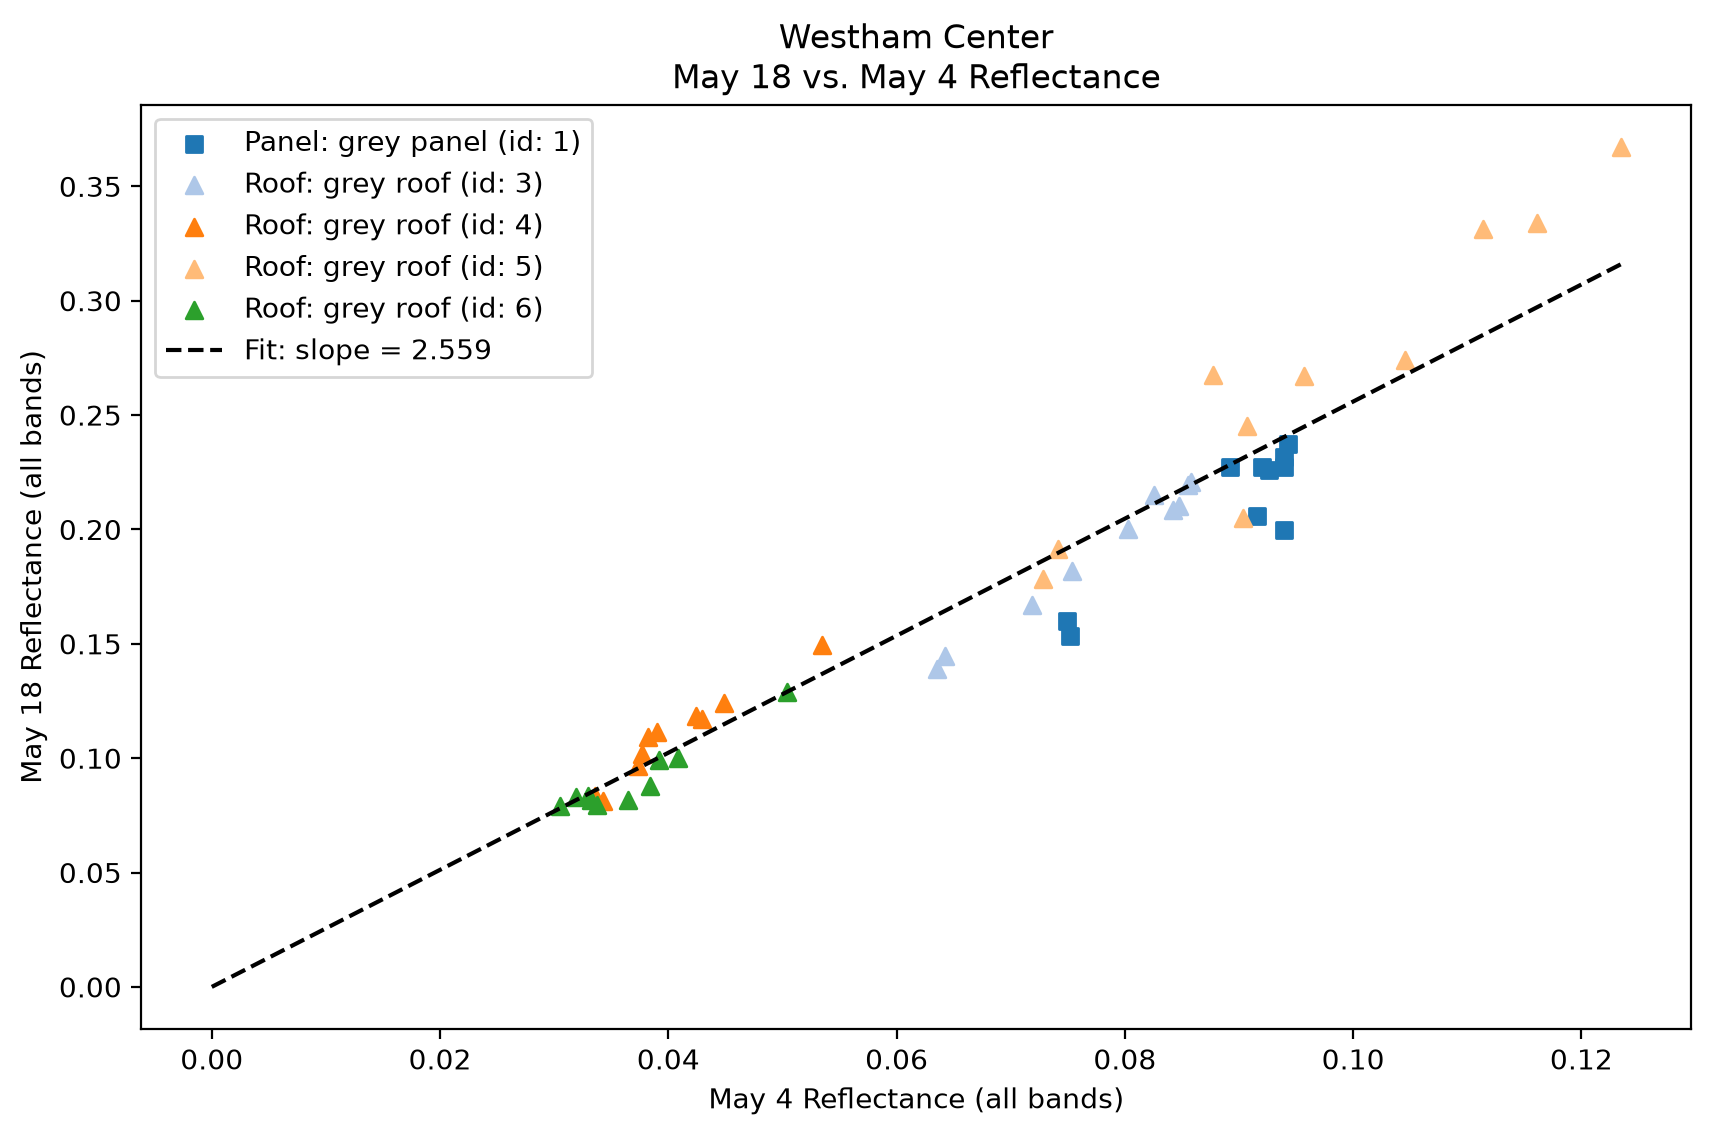

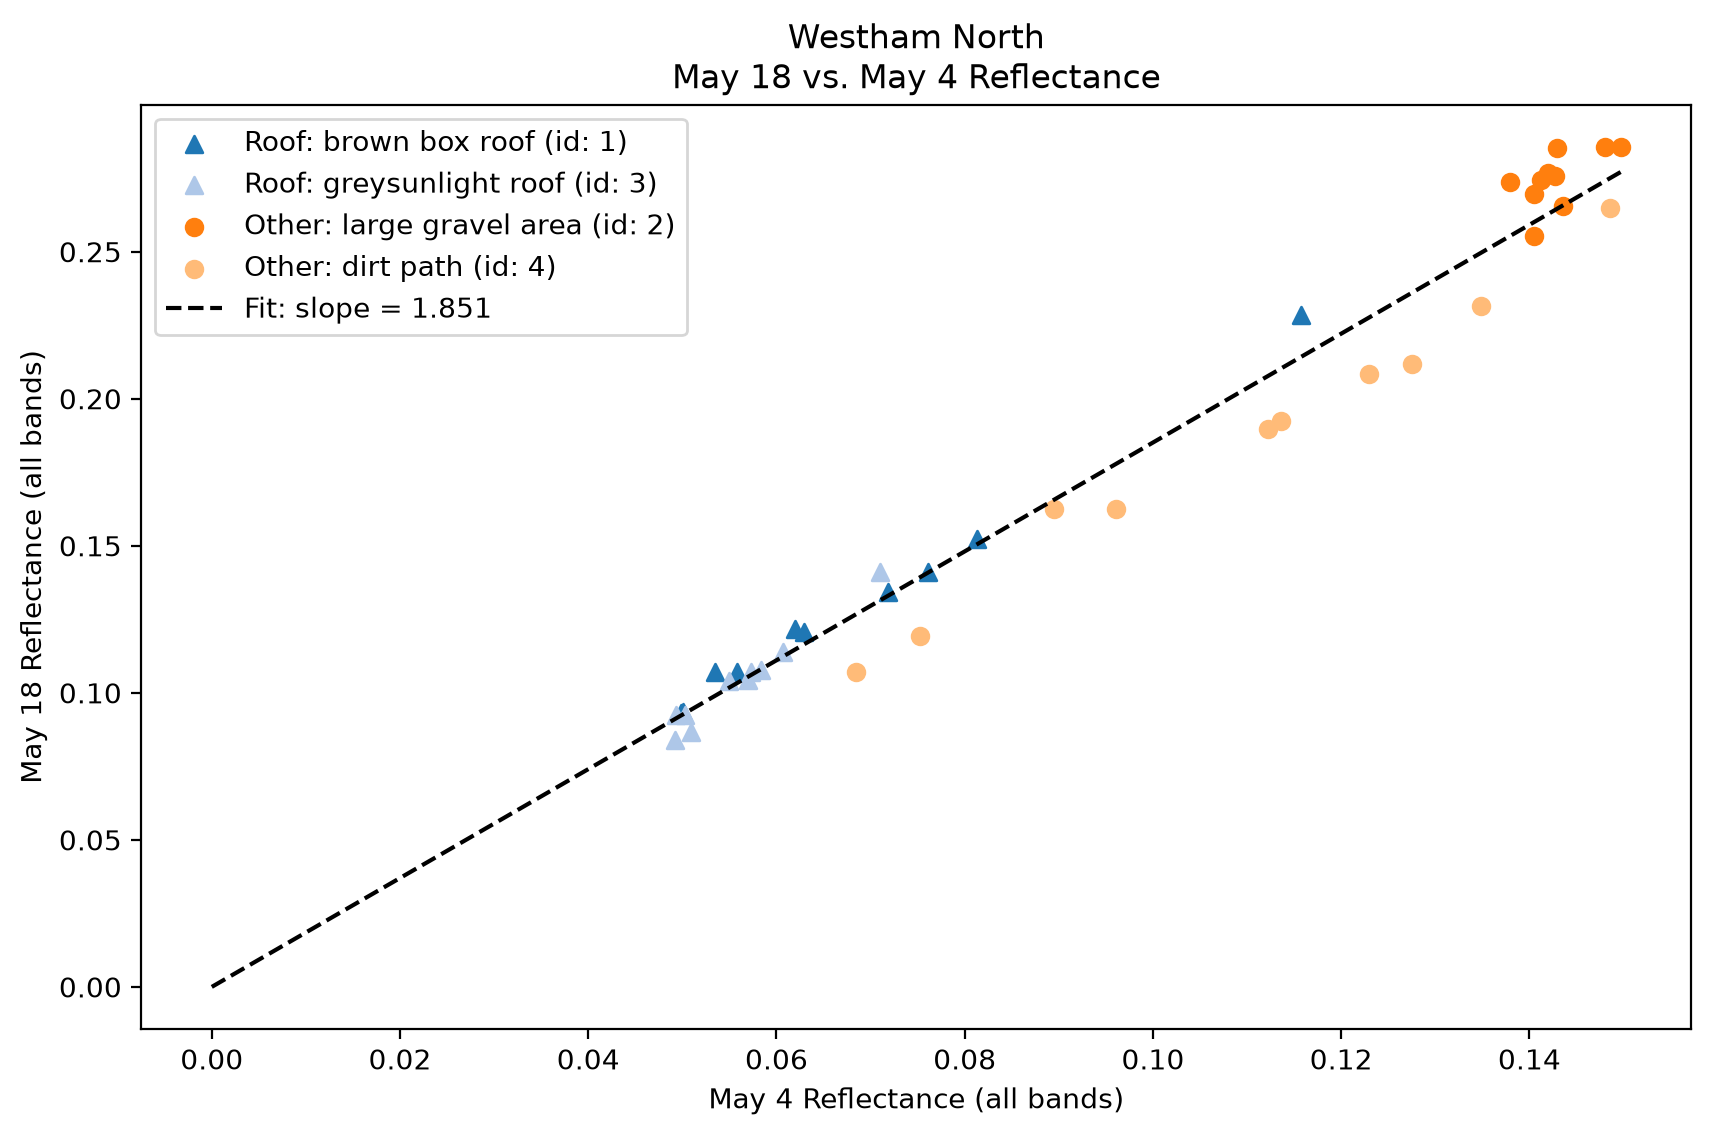

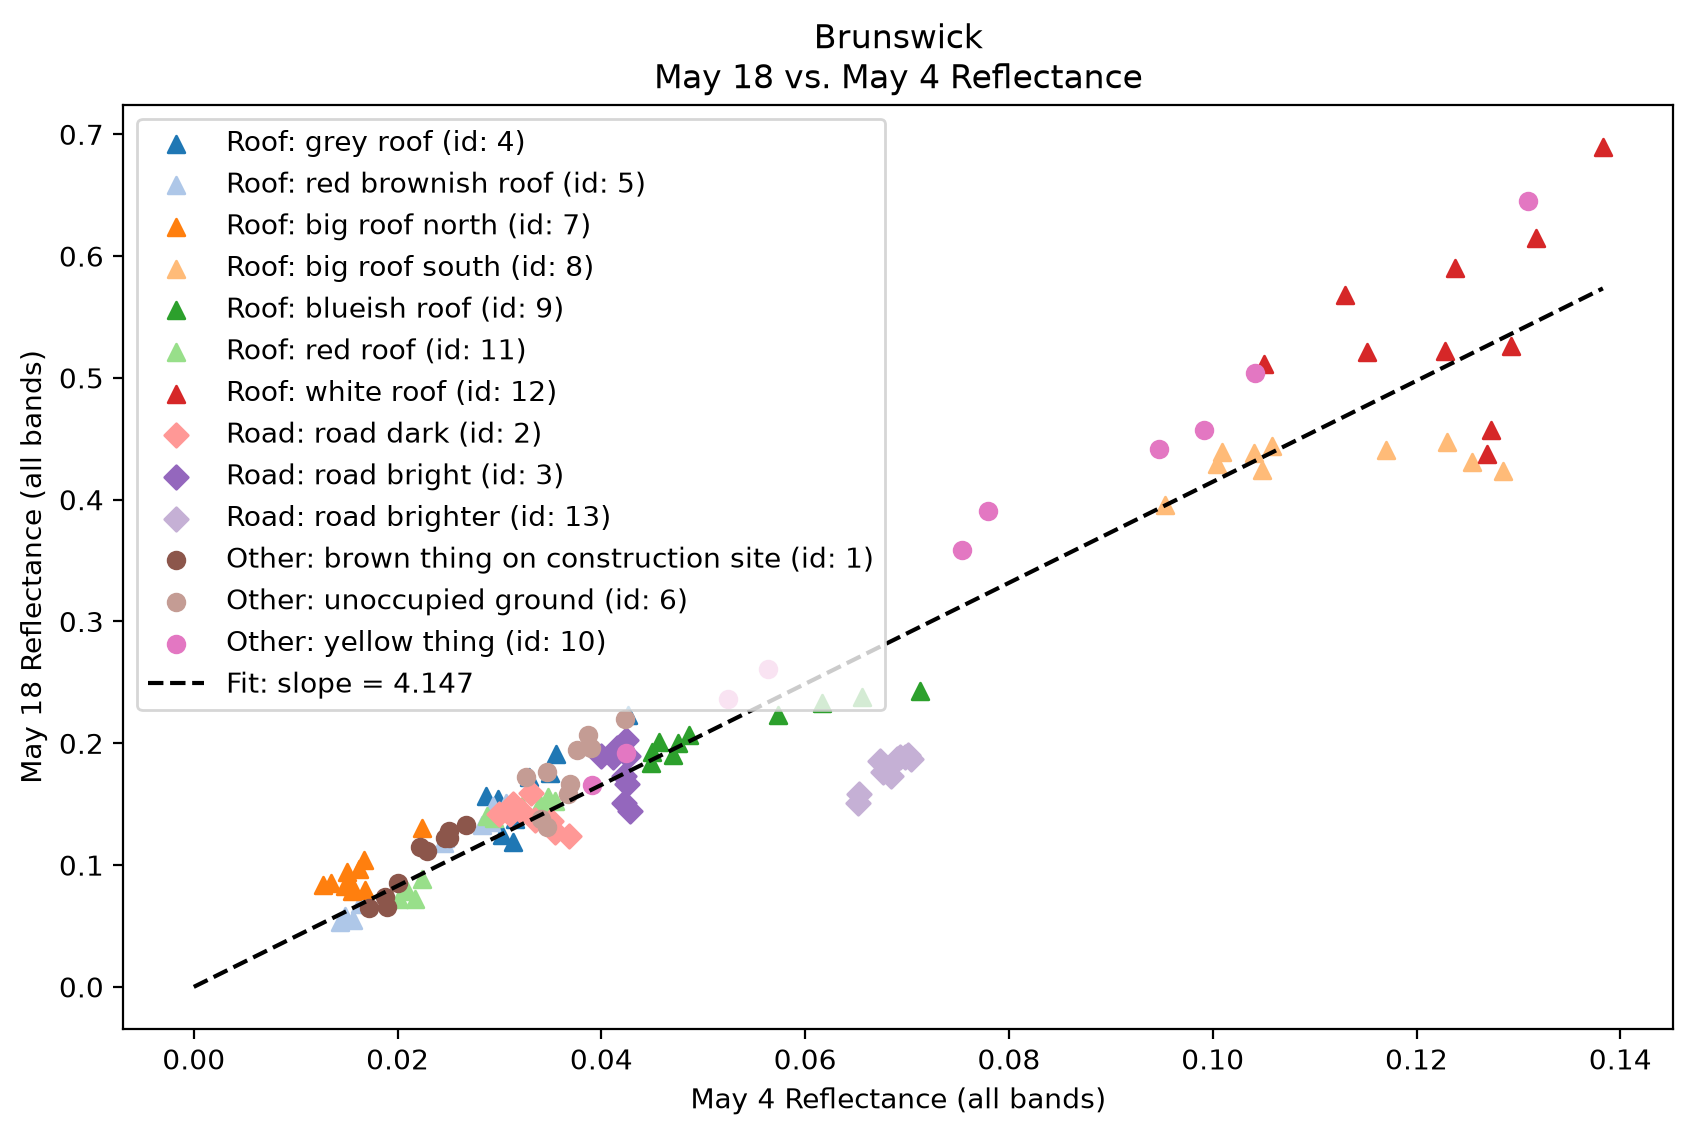

In [10]:
# Loop over areas but consider all bands at once, and fit a slope (linear regression with intercept=0) for the relation between day 18 (y) and day 4 (x) reflectance, and plot the slope for each area
fit_intercept = False
colors = plt.cm.tab20.colors
object_type_colors = {
    "panel": "grey",
    "roof": "tab:orange",
    "road": "brown",
    "other": "tab:blue",
}
object_type_markers = {
    "panel": "s",
    "roof": "^",
    "road": "D",
    "other": "o",
}
for ikey, (key, df_band_mean) in enumerate(dfs_band_mean.items()):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = df_band_mean.xs(4, level=0, axis=1).values.reshape(-1, 1)
    y = df_band_mean.xs(18, level=0, axis=1).values.reshape(-1, 1)
    # Fit linear regression with intercept=0
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(x, y)
    slope = model.coef_[0][0]
    if fit_intercept:
        intercept = model.intercept_[0]
        print(
            f"{key}: slope = {slope:.3f}, intercept = {intercept:.3e} (%mean = {100 * intercept / np.mean(y):.1f})"
        )
    colorid = 0
    for itype, type_ in enumerate(dict_object_id_list_per_site_and_type[key].keys()):
        ids = dict_object_id_list_per_site_and_type[key][type_]
        valid_ids = [
            id
            for id in ids
            if (4, id) in df_band_mean.columns and (18, id) in df_band_mean.columns
        ]
        for iid, id_ in enumerate(valid_ids):
            description = gdfs_extracted_spectra[key][gdfs_extracted_spectra[key]["id"] == id_]["description"].values[0]
            x_id = df_band_mean.xs(4, level=0, axis=1)[id_]
            y_id = df_band_mean.xs(18, level=0, axis=1)[id_]
            ax.scatter(
                x_id,
                y_id,
                label=f"{type_.title()}: {description.lower()} (id: {id_})",
                color=colors[colorid],
                marker=object_type_markers[type_],
            )
            colorid += 1
    ax.plot(
        [0, x.max()],
        model.predict([[0], [x.max()]]),
        color="k",
        ls="--",
        label=f"Fit: slope = {slope:.3f}"
    )
    ax.set_xlabel("May 4 Reflectance (all bands)")
    ax.set_ylabel("May 18 Reflectance (all bands)")
    ax.set_title(f"{key.replace('_', ' ').title()}\nMay 18 vs. May 4 Reflectance")

    ax.legend()


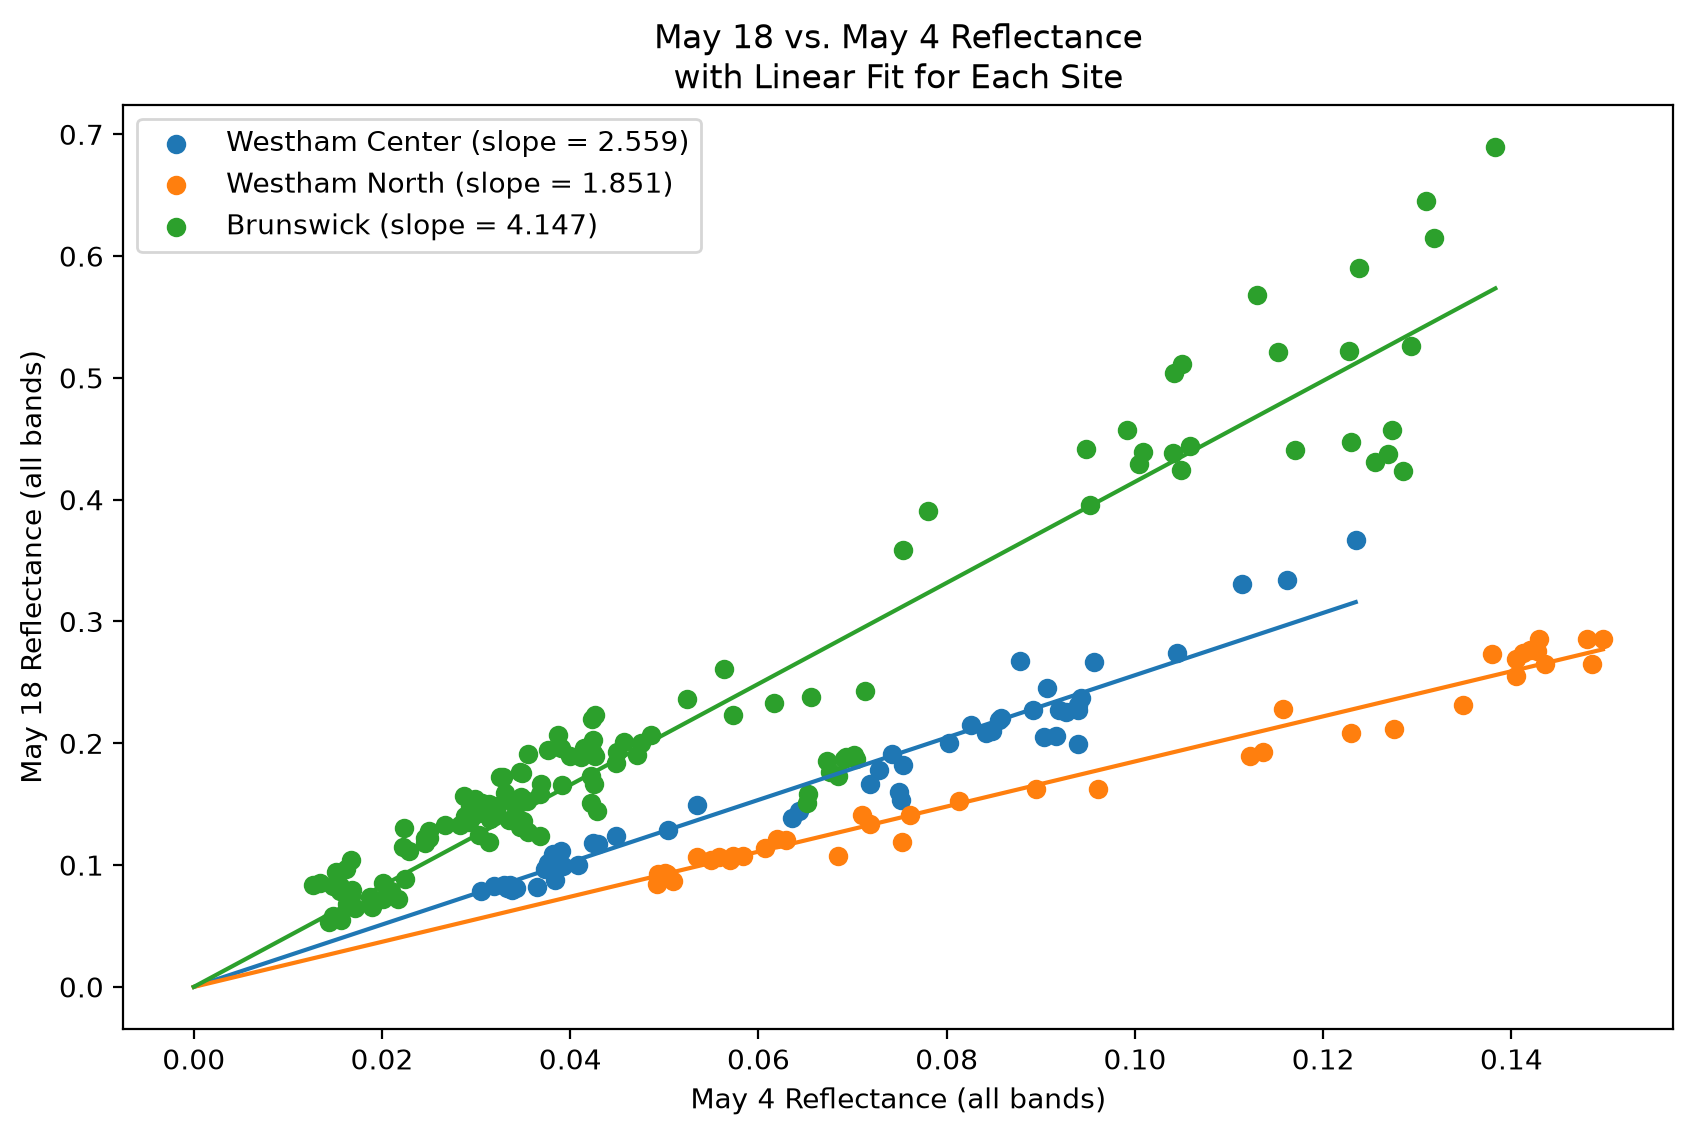

In [11]:
# Loop over areas but consider all bands at once, and fit a slope (linear regression with intercept=0) for the relation between day 18 (y) and day 4 (x) reflectance, and plot the slope for each area
fig, ax = plt.subplots(figsize=(10, 6))
fit_intercept=False
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for key, df_band_mean in dfs_band_mean.items():
    x = df_band_mean.xs(4, level=0, axis=1).values.reshape(-1, 1)
    y = df_band_mean.xs(18, level=0, axis=1).values.reshape(-1, 1)
    # Fit linear regression with intercept=0
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(x, y)
    slope = model.coef_[0][0]
    if fit_intercept:
        intercept = model.intercept_[0]
        print(
            f"{key}: slope = {slope:.3f}, intercept = {intercept:.3e} (%mean = {100*intercept/np.mean(y):.1f})"
        )
    # Scatter plot with fit, using same color
    scat_hdl = ax.scatter(
        x,
        y,
        label=f"{key.replace('_', ' ').title()} (slope = {slope:.3f})",
    )
    ax.plot(
        [0, x.max()], model.predict([[0], [x.max()]]), color=scat_hdl.get_facecolor()[0]
    )
ax.set_xlabel("May 4 Reflectance (all bands)")
ax.set_ylabel("May 18 Reflectance (all bands)")
ax.set_title("May 18 vs. May 4 Reflectance\nwith Linear Fit for Each Site")

ax.legend()



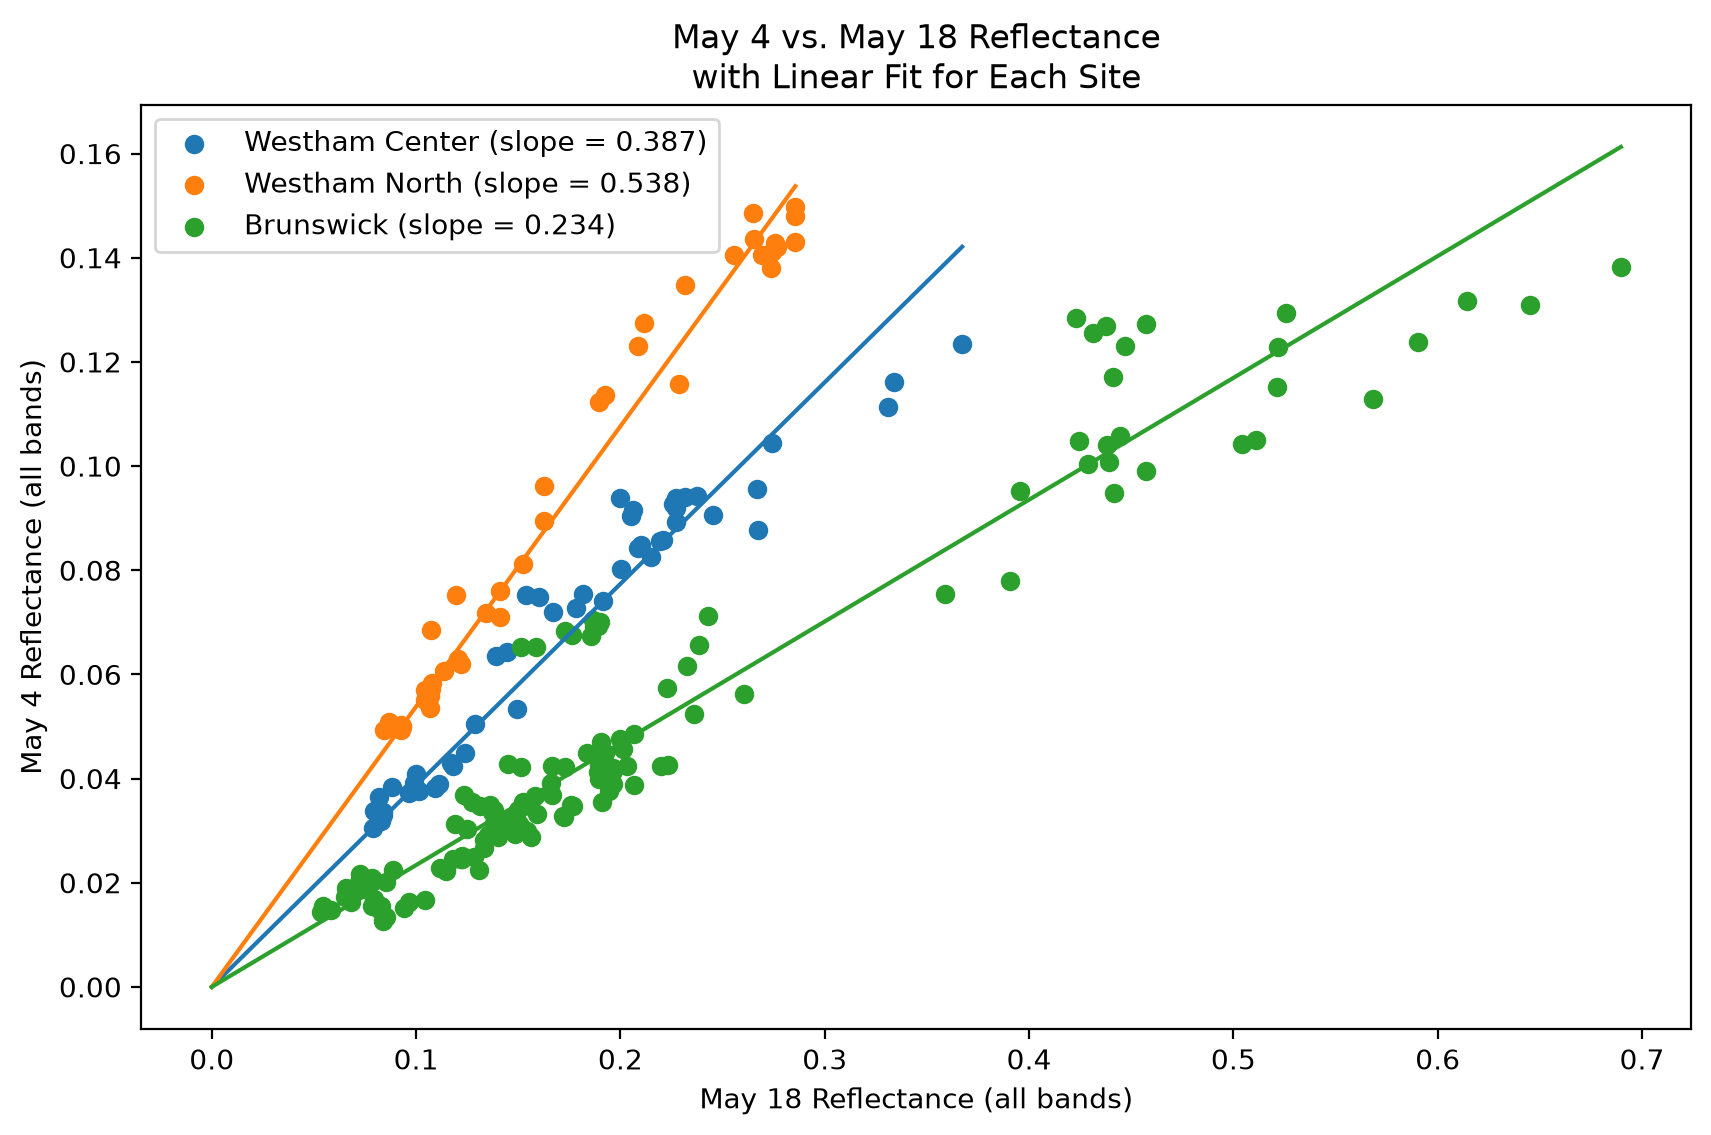

In [12]:
# Loop over areas but consider all bands at once, and fit a slope (linear regression with intercept=0) for the relation between day 4 (y) and day 18 (x) reflectance, and plot the slope for each area
fig, ax = plt.subplots(figsize=(10, 6))
for key, df_band_mean in dfs_band_mean.items():
    y = df_band_mean.xs(4, level=0, axis=1).values.reshape(-1, 1)
    x = df_band_mean.xs(18, level=0, axis=1).values.reshape(-1, 1)
    # Fit linear regression with intercept=0
    model = LinearRegression(fit_intercept=False)
    model.fit(x, y)
    slope = model.coef_[0][0]
    # Scatter plot with fit, using same color
    scat_hdl = ax.scatter(
        x,
        y,
        label=f"{key.replace('_', ' ').title()} (slope = {slope:.3f})",
    )
    ax.plot(
        [0, x.max()], model.predict([[0], [x.max()]]), color=scat_hdl.get_facecolor()[0]
    )
ax.set_xlabel("May 18 Reflectance (all bands)")
ax.set_ylabel("May 4 Reflectance (all bands)")
ax.set_title("May 4 vs. May 18 Reflectance\nwith Linear Fit for Each Site")

ax.legend()


# Compare to spectrometer data

In [13]:
# Read parquet file with pandas
df_groundtruth_resampled_spectra = pd.read_parquet(path_to_resampled_spectrometer_spectra)
df_groundtruth_resampled_spectra

station_id        black      grey                    
round                 2         1         2       1+2
wavelength_nm                                        
444            0.035356  0.223336  0.211112  0.217224
475            0.035682  0.226344  0.214988  0.220666
531            0.036656  0.237120  0.227201  0.232161
560            0.037157  0.241899  0.231500  0.236699
650            0.038880  0.242772  0.233315  0.238043
668            0.039205  0.242159  0.233067  0.237613
705            0.039982  0.241411  0.233257  0.237334
717            0.040315  0.240848  0.234042  0.237445
740            0.040985  0.239827  0.234878  0.237352
842            0.043067  0.237688  0.236094  0.236891

In [14]:
# Find ids in gdfs_extracted_spectra['westham_center'] that contains 'panel' in the description
grey_panel_round1_id = gdfs_extracted_spectra["westham_center"].query(
    "description.str.contains('panel', case=False, na=False) and day == 4"
).id.iloc[0]
grey_panel_round2_id = gdfs_extracted_spectra["westham_center"].query(
    "description.str.contains('panel', case=False, na=False) and day == 18"
).id.iloc[0]
black_panel_round2_id = (
    gdfs_extracted_spectra["westham_center"]
    .query(
        "description.str.contains('black panel', case=False, na=False) and day == 18"
    )
    .id.iloc[0]
)


In [15]:
# Build a dataframe with a multiindex column (station_id, round (1, 2, and 1+2)) and wavelength_nm as index, that stores the mean reflectance for each panel type (grey and black) and round (1, 2, and 1+2)
df_panels_from_drone = pd.DataFrame(
    index=pd.Index(MICASENSE_CENTER_WAVELENGTHS, name="wavelength_nm"),
    columns=pd.MultiIndex.from_tuples(
        [
            ("black", "2"),
            ("grey", "1"),
            ("grey", "2"),
            ("grey", "1+2"),
        ],
        names=["station_id", "round"],
    )
)


df_panels_from_drone[('black', '2')] = dfs_spectra['westham_center'].xs('mean', level=2, axis=1).loc[:, (18, black_panel_round2_id)]
df_panels_from_drone[('grey', '1')] = dfs_spectra['westham_center'].xs('mean', level=2, axis=1).loc[:, (4, grey_panel_round1_id)]
df_panels_from_drone[('grey', '2')] = dfs_spectra['westham_center'].xs('mean', level=2, axis=1).loc[:, (18, grey_panel_round2_id)]
df_panels_from_drone[('grey', '1+2')] = df_panels_from_drone[('grey', '1')].add(df_panels_from_drone[('grey', '2')], fill_value=0).div(2)

Assuming the true reflectance $\rho_i$ of the band i, for the grey (G) and black (B) panels, and the measured ones from the drone imageries $r$, are related by:

$\rho_{\mathrm{G},i} = a_i \times r_{\mathrm{G},i} + b_i$ 

$\rho_{\mathrm{B},i} = a_i \times r_{\mathrm{B},i} + b_i$ 

--> $a_i = \frac{\rho_{\mathrm{G},i}-\rho_{\mathrm{B},i}}{r_{\mathrm{G},i}-r_{\mathrm{B},i}}$ 

--> $b_i = \rho_{\mathrm{G},i}-a_i \times r_{\mathrm{G},i}$ 

In [16]:
rG = df_panels_from_drone[('grey', '2')]
rB = df_panels_from_drone[('black', '2')]
rhoG = df_groundtruth_resampled_spectra[('grey', '2')]
rhoB = df_groundtruth_resampled_spectra[('black', '2')]

ai = (rhoG - rhoB) / (rG - rB)
bi = rhoG - ai * rG

radiometric_correction_factors = pd.DataFrame(
    index=pd.Index(MICASENSE_CENTER_WAVELENGTHS, name="wavelength_nm"),
    columns=['slope', 'intercept'],
)
radiometric_correction_factors['slope'] = ai
radiometric_correction_factors['intercept'] = bi
radiometric_correction_factors.round(3)

,slope,intercept
wavelength_nm,,
444,1.721,-0.053
475,1.621,-0.045
531,1.246,-0.029
560,1.305,-0.029
650,1.137,-0.023
668,1.114,-0.020
705,1.157,-0.030
717,1.153,-0.028
740,1.187,-0.040


In [17]:
# # Apply radiometric_correction_factors to df_panels_from_drone to get a new dataframe with the same structure but corrected reflectance values
# df_panels_from_drone_corrected = pd.DataFrame(
#     index=pd.Index(MICASENSE_CENTER_WAVELENGTHS, name="wavelength_nm"),
#     columns=df_panels_from_drone.columns,
# )
# for station_id, round in df_panels_from_drone.columns:
#     df_panels_from_drone_corrected.loc[:, (station_id, round)] = (
#         radiometric_correction_factors['slope'] * df_panels_from_drone.loc[:, (station_id, round)]
#         + radiometric_correction_factors['intercept']
#     )


Text(0, 0.5, 'Reflectance')

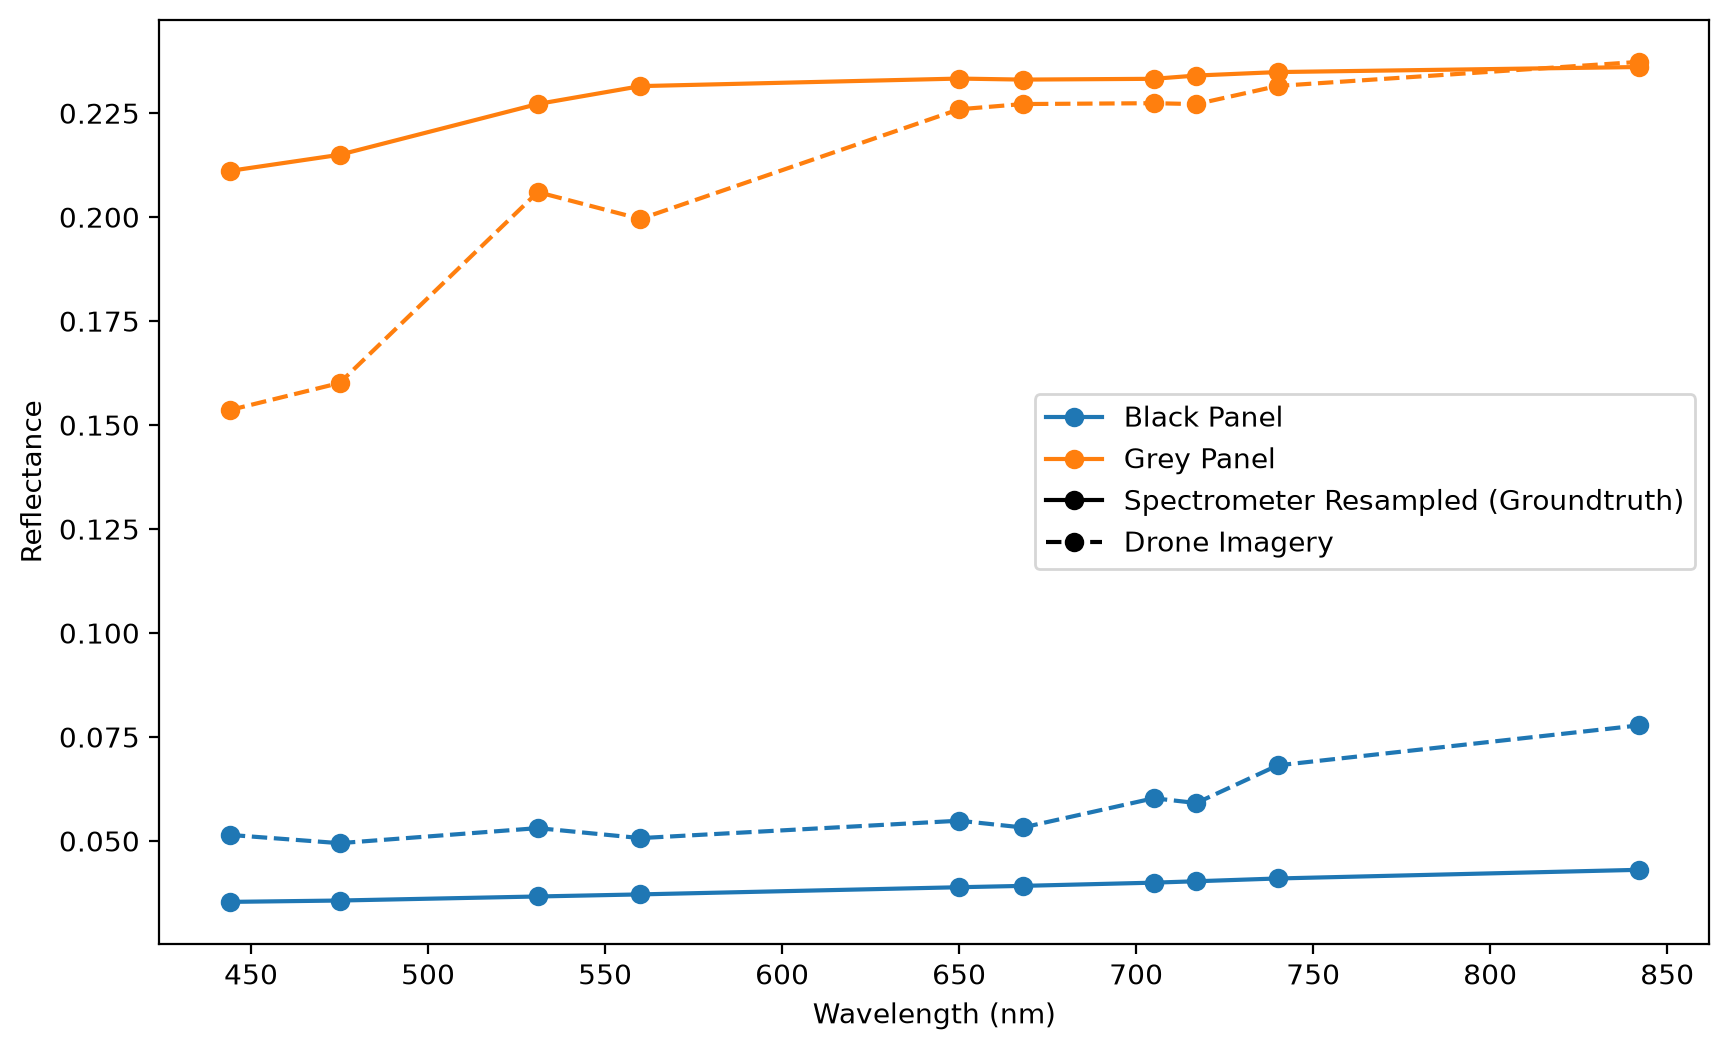

In [18]:
# Visualize reflectance spectra for panels at ground 2
fig, ax = plt.subplots(figsize=(10, 6))
round_ = 2
for station_id in df_panels_from_drone.columns.get_level_values(0).unique():
    # Ground truth
    mean_spectrum = df_groundtruth_resampled_spectra.loc[:, (station_id, str(round_))]
    plt_hdl = ax.plot(
        MICASENSE_CENTER_WAVELENGTHS,
        mean_spectrum,
        "o-",
        label=f"{station_id.title()} Panel",
    )

    # Drone spectrum,, same color as ground truth, but with a dashed line
    color = plt_hdl[0].get_color()
    mean_spectrum = df_panels_from_drone.loc[:, (station_id, str(round_))]
    ax.plot(
        MICASENSE_CENTER_WAVELENGTHS,
        mean_spectrum,
        "o--",
        color=color,
    )
# Add line for legend to show ground truth vs drone
groundtruth_hdl = ax.plot(
    [], [], "o-", color="k", label="Spectrometer Resampled (Groundtruth)"
)
drone_hdl = ax.plot([], [], "o--", color="k", label="Drone Imagery")
ax.legend()
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")

# # Add the table of correction factors to the figure, with slope and intercept values rounded to 3 decimals
# table_data = radiometric_correction_factors.round(3).reset_index().values.tolist()
# table = ax.table(
#     cellText=table_data,
#     colLabels=["Wavelength (nm)", "Slope", "Intercept"],
#     cellLoc="center",
#     loc="bottom",
#     bbox=[0.0, -0.5, 1, 0.3],
# )
# table.auto_set_font_size(False)
# table.set_fontsize(10)

# Before/After panel spectra during Round 2

In [19]:
# read path_to_before_after_panel_extracted_spectra as other geojson, except the prefix are "before_" and "after_" now
gdf_before_after_panel_extracted_spectra = gpd.read_file(path_to_before_after_panel_extracted_spectra).rename(columns={"Day": "day", "Descrip": "description"})
gdf_before_after_panel_extracted_spectra

df_before_after_panel_extracted_spectra = pd.DataFrame(
    index=pd.Index(MICASENSE_CENTER_WAVELENGTHS, name="wavelength_nm"),
    columns=pd.MultiIndex.from_product(
        [
            ["black", "grey"], ["before", "after"],
            ["mean", "std"],
        ],
    ),
)
df_before_after_panel_extracted_spectra

for index, row in gdf_before_after_panel_extracted_spectra.iterrows():
    description = row["description"]
    if "black" in description.lower():
        color = "black"
    elif "grey" in description.lower():
        color = "grey"
    else:
        continue
    for time in ["before", "after"]:
        mean_columns = [
            col
            for col in gdf_before_after_panel_extracted_spectra.columns
            if col.startswith(time) and col.endswith("mean")
        ]
        std_columns = [
            col
            for col in gdf_before_after_panel_extracted_spectra.columns
            if col.startswith(time) and col.endswith("stdev")
        ]
        mean_spectrum = row[mean_columns].astype(float)
        mean_spectrum.index = MICASENSE_CENTER_WAVELENGTHS
        df_before_after_panel_extracted_spectra.loc[:, (color, time, 'mean')] = mean_spectrum
        std_spectrum = row[std_columns].astype(float)
        std_spectrum.index = MICASENSE_CENTER_WAVELENGTHS
        df_before_after_panel_extracted_spectra.loc[:, (color, time, 'std')] = std_spectrum


df_before_after_panel_extracted_spectra = df_before_after_panel_extracted_spectra.astype(float)
df_before_after_panel_extracted_spectra

black                                    grey            \
                 before               after              before             
                   mean       std      mean       std      mean       std   
wavelength_nm                                                               
444            0.050741  0.004121  0.052076  0.002281  0.145888  0.000057   
475            0.049900  0.005024  0.049917  0.002953  0.155230  0.000070   
531            0.050488  0.005550  0.053114  0.003020  0.201557  0.000103   
560            0.050458  0.004710  0.050846  0.002137  0.190610  0.000076   
650            0.052907  0.004816  0.055238  0.002379  0.230915  0.005816   
668            0.053765  0.004773  0.053662  0.002756  0.229912  0.004609   
705            0.059698  0.004793  0.061360  0.003181  0.233112  0.005175   
717            0.060273  0.005609  0.059560  0.002671  0.233265  0.006820   
740            0.066506  0.004922  0.068015  0.003385  0.237313  0.008828   
842            0.084020  0.005576  0.081191  0.002418  0.245846  0.005324   

                                   
                  after            
                   mean       std  
wavelength_nm                      
444            0.167242  0.000093  
475            0.170815  0.000075  
531            0.220017  0.002165  
560            0.216069  0.000597  
650            0.233165  0.005854  
668            0.232594  0.006928  
705            0.236225  0.005190  
717            0.237937  0.008000  
740            0.243138  0.005158  
842            0.250705  0.007466

wavelength_nm
444    0.039365
475    0.045043
531    0.051254
560    0.039669
650    2.518765
668    2.004854
705    2.219976
717    2.923823
740    3.720166
842    2.165404
dtype: float64
wavelength_nm
444    0.055359
475    0.043962
531    0.984112
560    0.276185
650    2.510781
668    2.978527
705    2.196903
717    3.362212
740    2.121401
842    2.977986
dtype: float64


Text(0.5, 1.0, 'Ground-Truth vs. Spectra From Imagery')

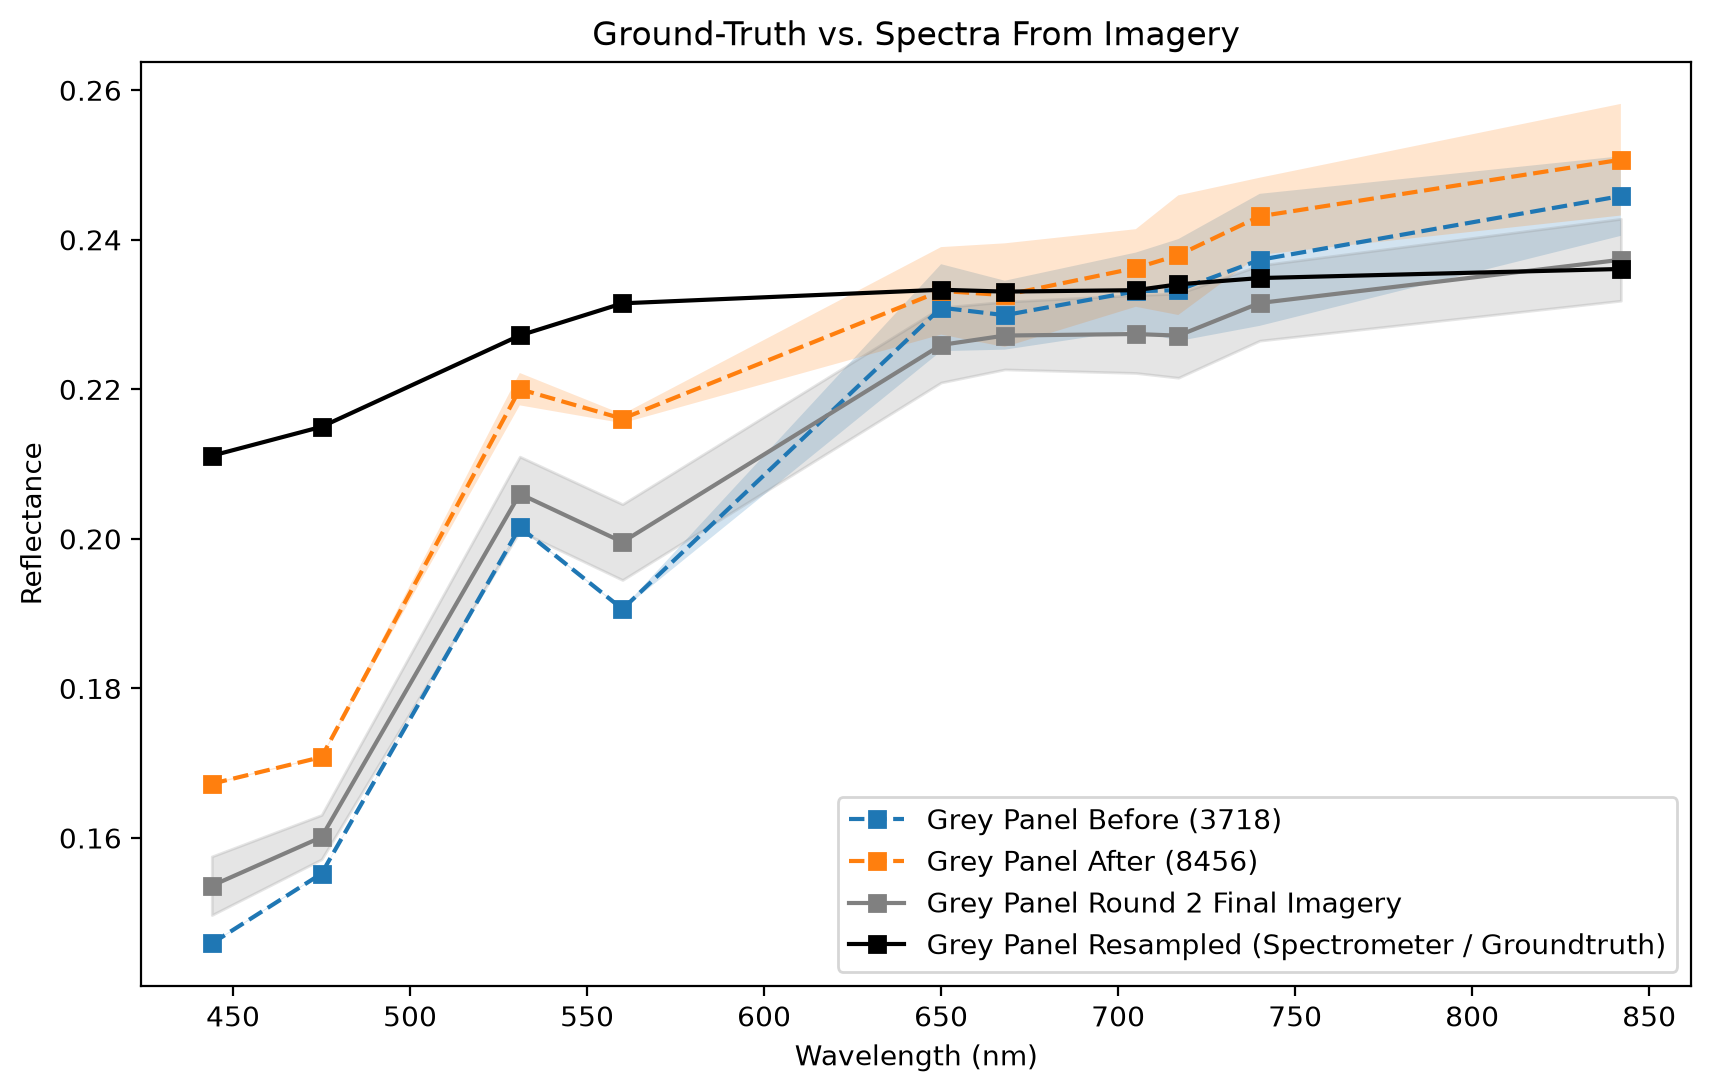

In [32]:
# Visualize before and after spectra for black and grey panels, with mean and std

black_panel_only = False
grey_panel_only = True

fig, ax = plt.subplots(figsize=(10, 6))
for color in ["black", "grey"]:
    if black_panel_only and color != "black":
        continue
    if grey_panel_only and color != "grey":
        continue
    for time in ["before", "after"]:
        mean_spectrum = df_before_after_panel_extracted_spectra.loc[:, (color, time, 'mean')]
        std_spectrum = df_before_after_panel_extracted_spectra.loc[:, (color, time, 'std')]
        std_over_mean_spectrum_pc = 100 * std_spectrum / mean_spectrum
        print(std_over_mean_spectrum_pc)
        ax.plot(
            MICASENSE_CENTER_WAVELENGTHS,
            mean_spectrum,
            marker="o" if color == "black" else "s",
            ls="--", #"-" if time == "before" else "--",
            label=f"{color.title()} Panel {time.title()} ({'3718' if time == 'before' else '8456'})",
        )
        ax.fill_between(
            MICASENSE_CENTER_WAVELENGTHS,
            mean_spectrum - std_spectrum,
            mean_spectrum + std_spectrum,
            alpha=0.2,
        )

    if color == 'grey':

        mean_grey_final_imagery = (
            dfs_spectra["westham_center"]
            .xs("mean", level=2, axis=1)
            .loc[:, (18, grey_panel_round2_id)]
        )
        std_grey_final_imagery = (
            dfs_spectra["westham_center"]
            .xs("std", level=2, axis=1)
            .loc[:, (18, grey_panel_round2_id)]
        )
        ax.plot(
            MICASENSE_CENTER_WAVELENGTHS,
            mean_grey_final_imagery,
            "s-",
            color="grey",
            label="Grey Panel Round 2 Final Imagery",
        )
        ax.fill_between(
            MICASENSE_CENTER_WAVELENGTHS,
            mean_grey_final_imagery - std_grey_final_imagery,
            mean_grey_final_imagery + std_grey_final_imagery,
            alpha=0.2,
            color="grey",
        )

    elif color == 'black':

        # Same for black panel
        mean_black_final_imagery = (
            dfs_spectra["westham_center"]
            .xs("mean", level=2, axis=1)
            .loc[:, (18, black_panel_round2_id)]
        )
        std_black_final_imagery = (
            dfs_spectra["westham_center"]
            .xs("std", level=2, axis=1)
            .loc[:, (18, black_panel_round2_id)]
        )
        ax.plot(
            MICASENSE_CENTER_WAVELENGTHS,
            mean_black_final_imagery,
            "o-",
            color="grey",
            label="Black Panel Round 2 Final Imagery",
        )
        ax.fill_between(
            MICASENSE_CENTER_WAVELENGTHS,
            mean_black_final_imagery - std_black_final_imagery,
            mean_black_final_imagery + std_black_final_imagery,
            alpha=0.2,
            color="grey",
        )

    # Add spectrometer resampled spectra for black and grey panels
    if not black_panel_only:
        grey_mean_spectrum_resampled = df_groundtruth_resampled_spectra.loc[:, ("grey", "2")]
        ax.plot(
            MICASENSE_CENTER_WAVELENGTHS,
            grey_mean_spectrum_resampled,
            "s-",
            color="k",
            label="Grey Panel Resampled (Spectrometer / Groundtruth)",
        )
    if not grey_panel_only:
        black_mean_spectrum_resampled = df_groundtruth_resampled_spectra.loc[:, ("black", "2")]
        ax.plot(
            MICASENSE_CENTER_WAVELENGTHS,
            black_mean_spectrum_resampled,
            "o-",
            color="k",
            label="Black Panel Resampled (Spectrometer / Groundtruth)",
        )

ax.legend()

# if not black_panel_only:
#     ax.set_ylim(bottom=0)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title("Ground-Truth vs. Spectra From Imagery")

# # Add the grey panel spectra we have from round 2 in earlier dataset for Westham Center
# if black_panel_only:
#     pass
# else:
#     mean_grey_final_imagery = (
#         dfs_spectra["westham_center"]
#         .xs("mean", level=2, axis=1)
#         .loc[:, (18, grey_panel_round2_id)]
#     )
#     std_grey_final_imagery = (
#         dfs_spectra["westham_center"]
#         .xs("std", level=2, axis=1)
#         .loc[:, (18, grey_panel_round2_id)]
#     )
#     ax.plot(
#         MICASENSE_CENTER_WAVELENGTHS,
#         mean_grey_final_imagery,
#         "s-",
#         color="grey",
#         label="Grey Panel Round 2 Final Imagery",
#     )
#     ax.fill_between(
#         MICASENSE_CENTER_WAVELENGTHS,
#         mean_grey_final_imagery - std_grey_final_imagery,
#         mean_grey_final_imagery + std_grey_final_imagery,
#         alpha=0.2,
#         color="grey",
#     )

# # Same for black panel
# mean_black_final_imagery = (
#     dfs_spectra["westham_center"]
#     .xs("mean", level=2, axis=1)
#     .loc[:, (18, black_panel_round2_id)]
# )
# std_black_final_imagery = (
#     dfs_spectra["westham_center"]
#     .xs("std", level=2, axis=1)
#     .loc[:, (18, black_panel_round2_id)]
# )
# ax.plot(
#     MICASENSE_CENTER_WAVELENGTHS,
#     mean_black_final_imagery,
#     "o-",
#     color="black",
#     label="Black Panel Round 2 Final Imagery",
# )
# ax.fill_between(
#     MICASENSE_CENTER_WAVELENGTHS,
#     mean_black_final_imagery - std_black_final_imagery,
#     mean_black_final_imagery + std_black_final_imagery,
#     alpha=0.2,
#     color="black",
# )

# ax.legend()

# Compare calibration effects

In [21]:
path_to_badly_calibrated_resampled_spectrometer_spectra.exists()

True

In [22]:
list(path_to_badly_calibrated_resampled_spectrometer_spectra.parents[2].glob('*'))

[PosixPath('/home/coder/wesa-fup-restricted/data_test/processed/spectra/runs/2026-07-17T162053Z__git47ecadc__cfg5319719d'),
 PosixPath('/home/coder/wesa-fup-restricted/data_test/processed/spectra/runs/2026-07-21T160319Z__git293256c__cfg5319719d')]

In [23]:
df_badly_calibrated_resampled_spectra = pd.read_parquet(
    path_to_badly_calibrated_resampled_spectrometer_spectra
)
df_badly_calibrated_resampled_spectra

# Also load full spectra in both cases
df_panels_mean_full_spectra = pd.read_parquet(
    path_to_resampled_spectrometer_spectra.parents[0] / "panels_mean_full_spectra.parquet"
)
df_badly_calibrated_panels_mean_full_spectra = pd.read_parquet(
    path_to_badly_calibrated_resampled_spectrometer_spectra.parents[0] / "panels_mean_full_spectra.parquet"
)


In [24]:
# # For round 2 only, compare full spectra from the well-calibrated and badly-calibrated spectrometer, for both black and grey panels, in a single plot
# fig, ax = plt.subplots(figsize=(10, 6))
# for color in ["black", "grey"]:
#     mean_spectrum_well_calibrated = df_panels_mean_full_spectra.loc[:, (color, "2")]
#     mean_spectrum_badly_calibrated = df_badly_calibrated_panels_mean_full_spectra.loc[
#         :, (color, "2")
#     ]
#     ax.plot(
#         df_panels_mean_full_spectra.index,
#         mean_spectrum_well_calibrated,
#         "o-",
#         color=color,
#         label=f"{color.title()} - Cross-Calibration to get Westham Calibration",
#     )
#     ax.plot(
#         df_badly_calibrated_panels_mean_full_spectra.index,
#         mean_spectrum_badly_calibrated,
#         "s--",
#         color=color,
#         label=f"{color.title()} - Brunswick Calibration",
#     )
# ax.set_xlabel("Wavelength (nm)")
# ax.set_ylabel("Reflectance")
# ax.set_title("Calibration Effects")
# ax.legend()

# # For round 2 only, compare resampled spectra from the well-calibrated and badly-calibrated spectrometer, for both black and grey panels, in a single plot
# fig, ax = plt.subplots(figsize=(10, 6))
# for color in ["black", "grey"]:
#     mean_spectrum_well_calibrated = df_groundtruth_resampled_spectra.loc[:, (color, "2")]
#     mean_spectrum_badly_calibrated = df_badly_calibrated_resampled_spectra.loc[:, (color, "2")]
#     ax.plot(
#         MICASENSE_CENTER_WAVELENGTHS,
#         mean_spectrum_well_calibrated,
#         "o-",
#         color=color,
#         label=f"{color.title()} - Cross-Calibration to get Westham Calibration",
#     )
#     ax.plot(
#         MICASENSE_CENTER_WAVELENGTHS,
#         mean_spectrum_badly_calibrated,
#         "s--",
#         color=color,
#         label=f"{color.title()} - Brunswick Calibration",
#     )
# ax.set_xlabel("Wavelength (nm)")
# ax.set_ylabel("Reflectance")
# ax.set_title("Calibration Effects")
# ax.legend()

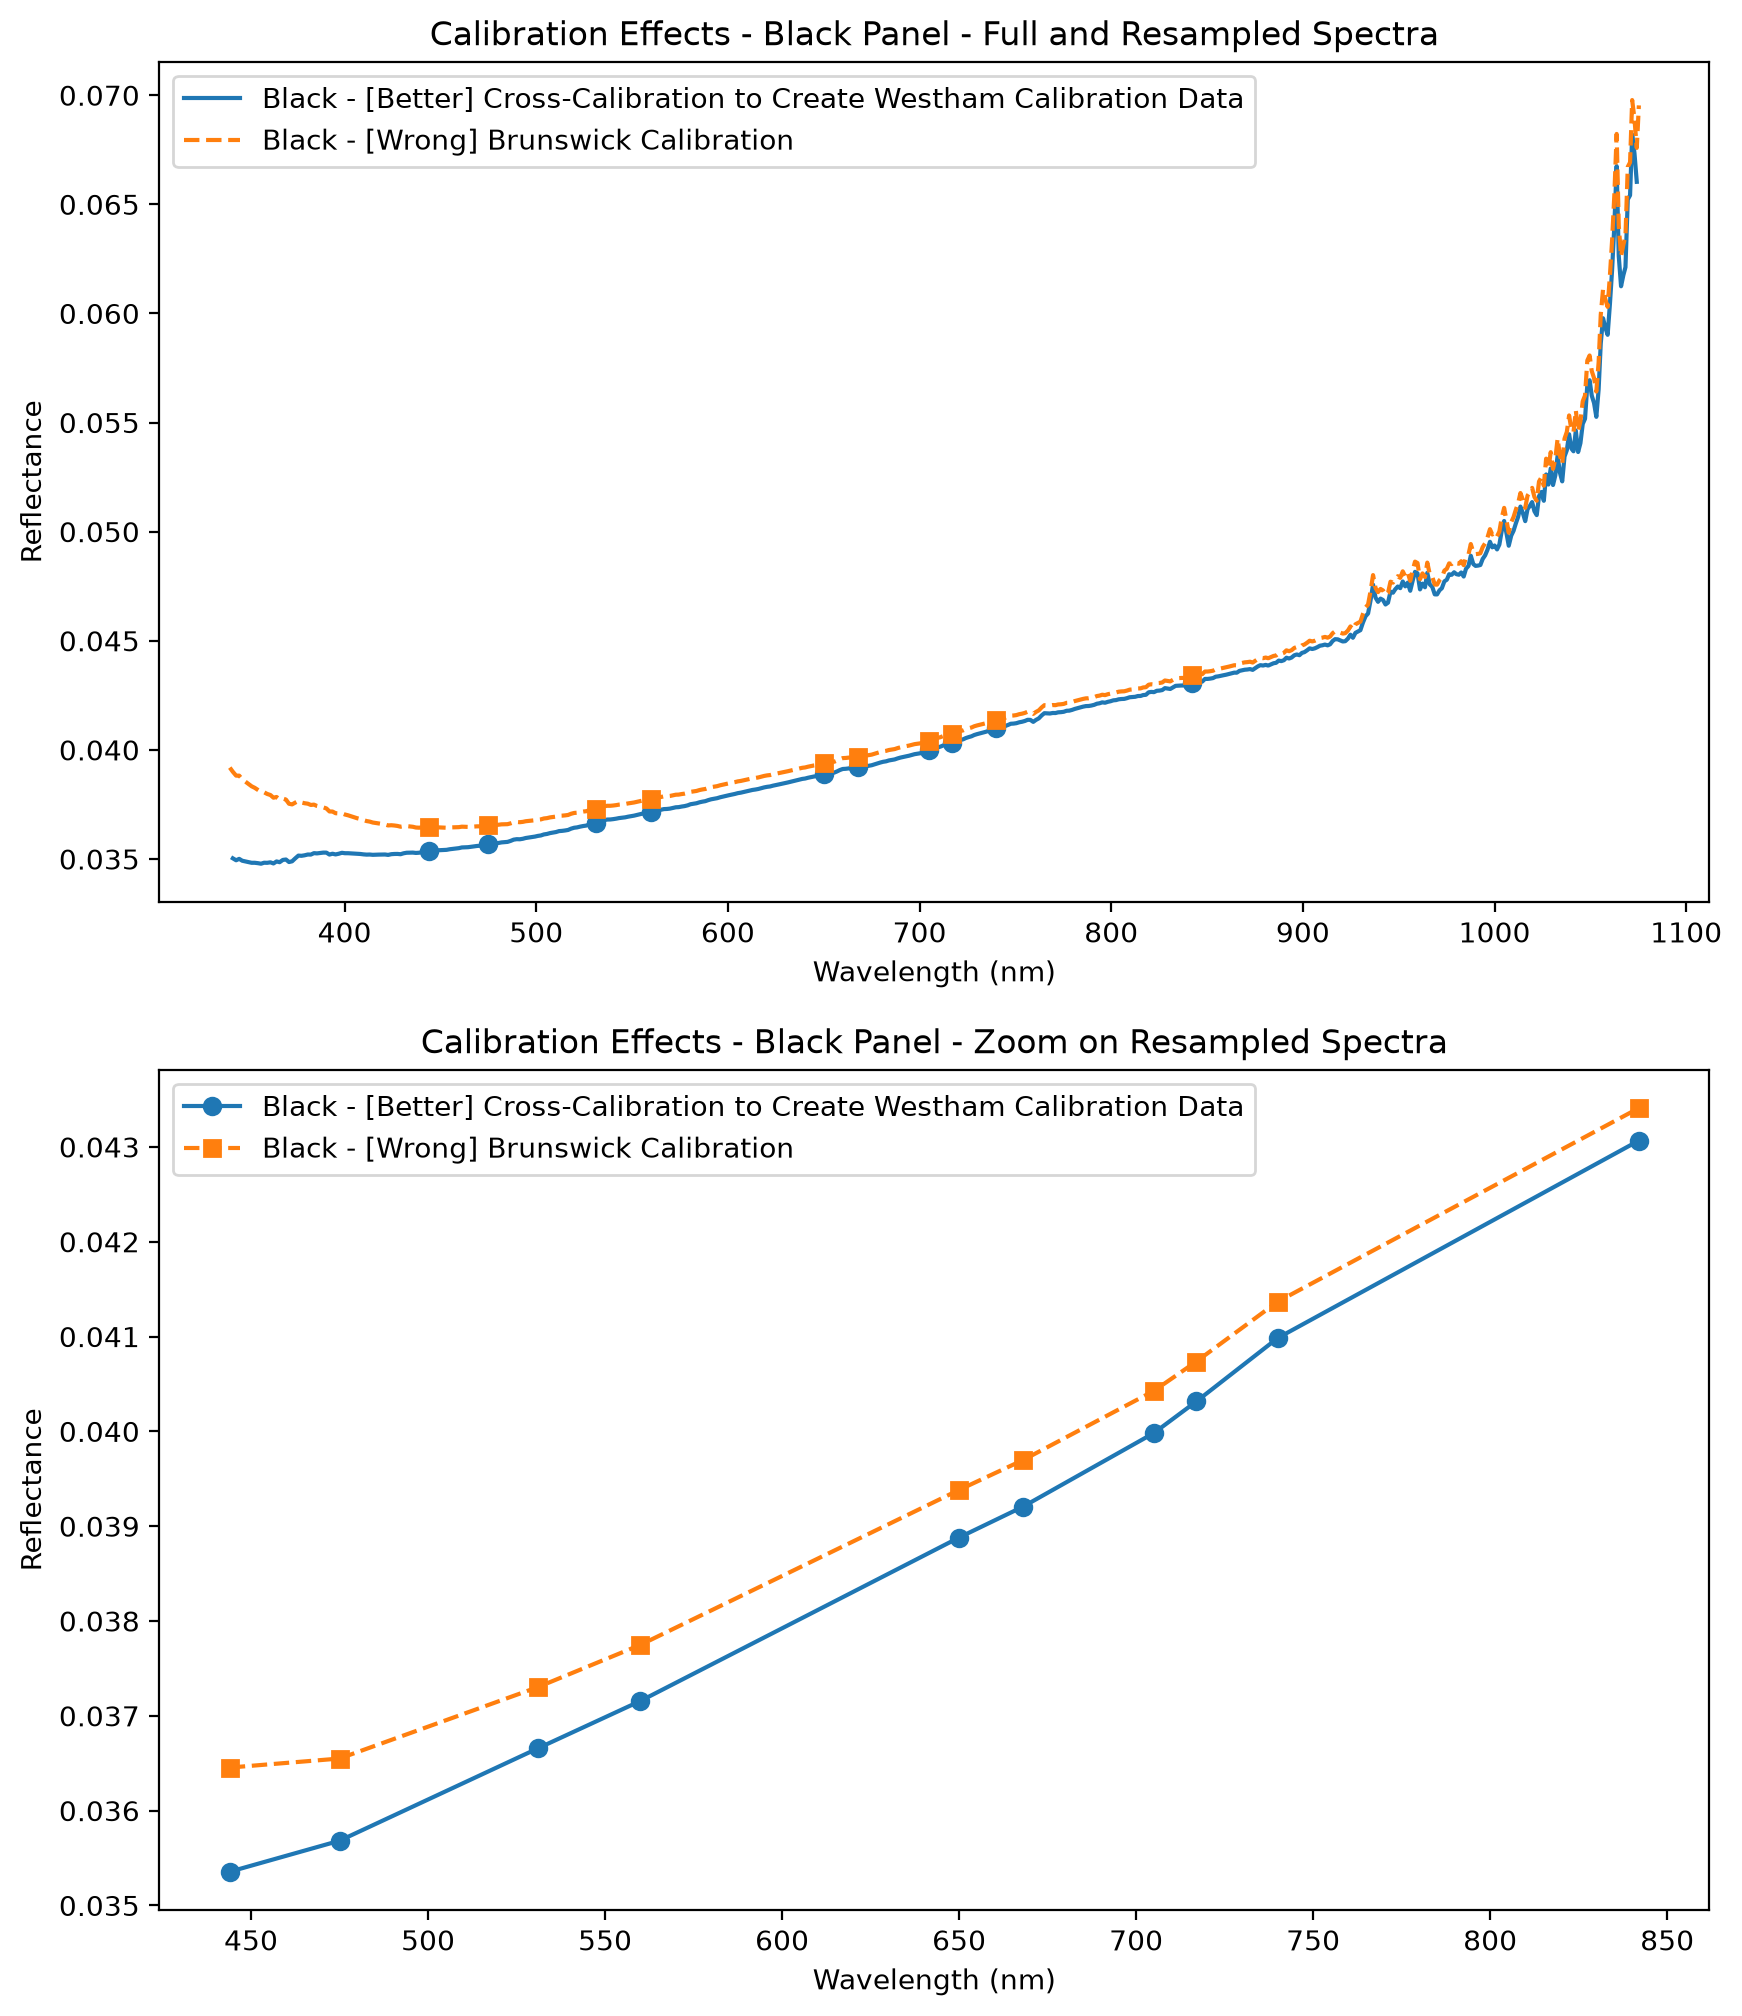

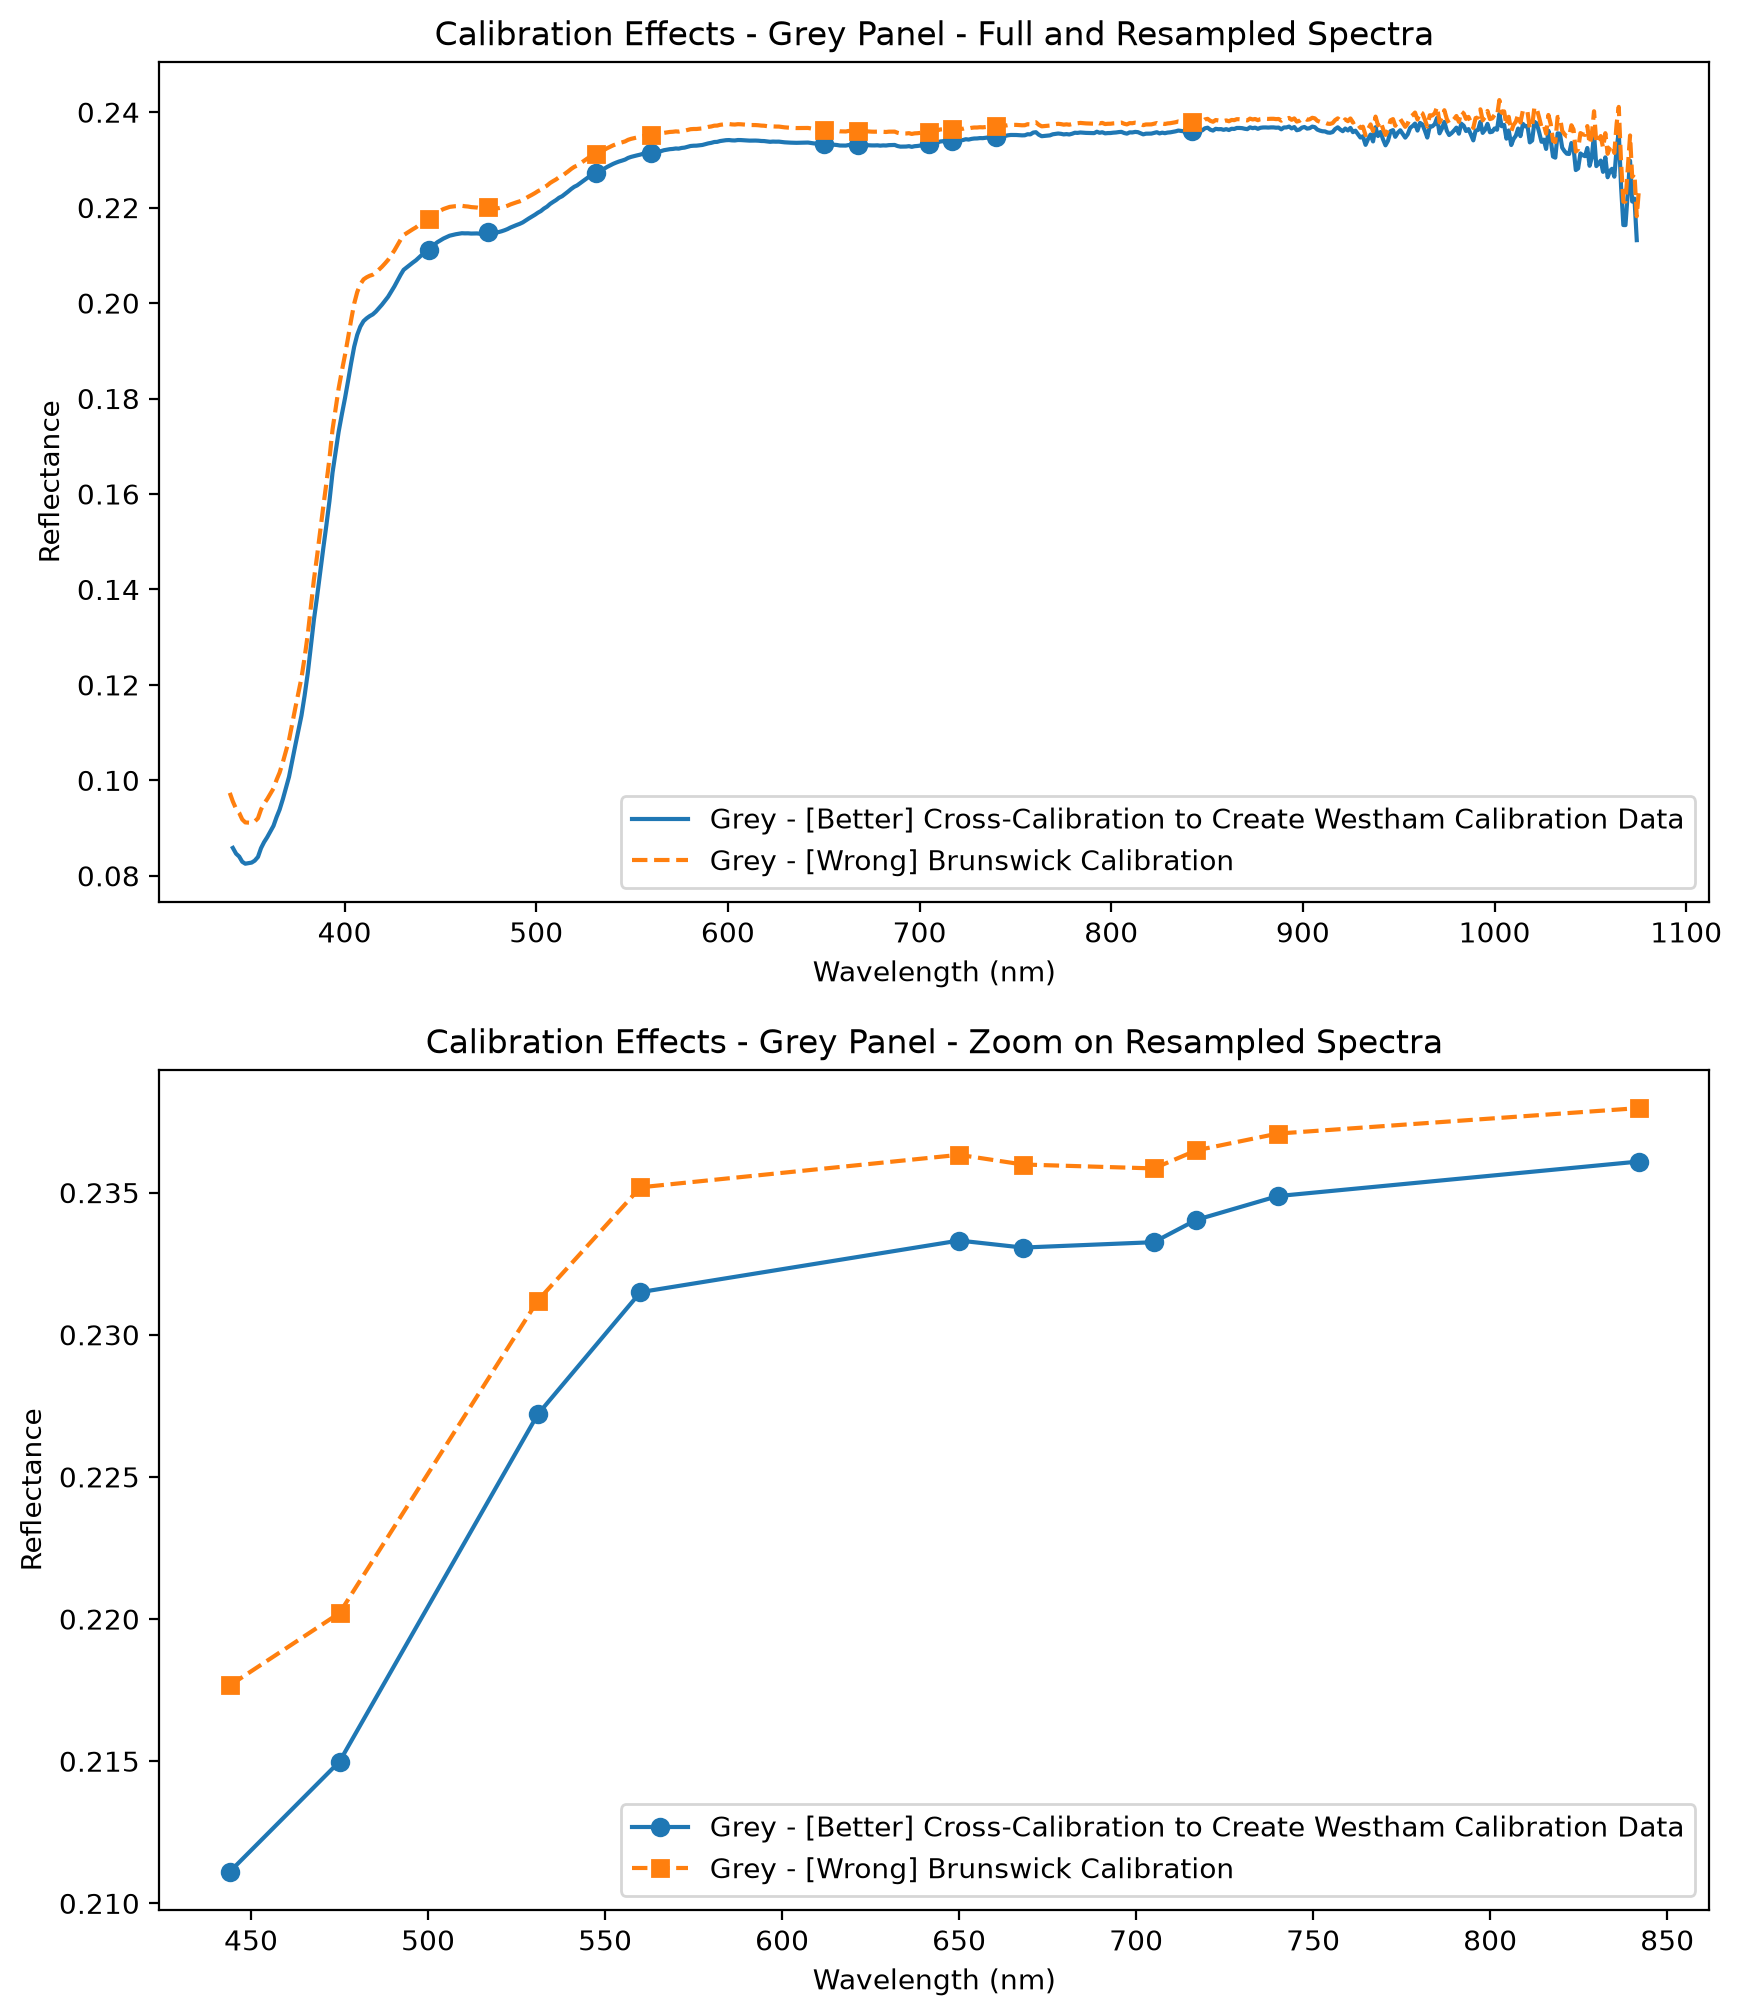

In [25]:
# For round 2 only, compare full and resample spectra from the well-calibrated and badly-calibrated spectrometer, for both black and grey panels, in a single plot
for icolor, color in enumerate(["black", "grey"]):
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))#, sharex=True, sharey=True)

    mean_spectrum_well_calibrated_full = df_panels_mean_full_spectra.loc[:, (color, "2")]
    mean_spectrum_badly_calibrated_full = (
        df_badly_calibrated_panels_mean_full_spectra.loc[:, (color, "2")]
    )

    mean_spectrum_well_calibrated_resampled = df_groundtruth_resampled_spectra.loc[
        :, (color, "2")
    ]
    mean_spectrum_badly_calibrated_resampled = (
        df_badly_calibrated_resampled_spectra.loc[:, (color, "2")]
    )

    hdl1 = axes[0].plot(
        df_panels_mean_full_spectra.index,
        mean_spectrum_well_calibrated_full,
        "-",
        label=f"{color.title()} - [Better] Cross-Calibration to Create Westham Calibration Data",
    )
    hdl2 = axes[0].plot(
        df_badly_calibrated_panels_mean_full_spectra.index,
        mean_spectrum_badly_calibrated_full,
        "--",
        label=f"{color.title()} - [Wrong] Brunswick Calibration",
    )
    axes[0].plot(
        MICASENSE_CENTER_WAVELENGTHS,
        mean_spectrum_well_calibrated_resampled,
        "o",
        color = hdl1[0].get_color(),
    )
    axes[0].plot(
        MICASENSE_CENTER_WAVELENGTHS,
        mean_spectrum_badly_calibrated_resampled,
        "s",
        color = hdl2[0].get_color(),
    )

    axes[1].plot(
        MICASENSE_CENTER_WAVELENGTHS,
        mean_spectrum_well_calibrated_resampled,
        "o-",
        label=f"{color.title()} - [Better] Cross-Calibration to Create Westham Calibration Data",
    )
    axes[1].plot(
        MICASENSE_CENTER_WAVELENGTHS,
        mean_spectrum_badly_calibrated_resampled,
        "s--",
        label=f"{color.title()} - [Wrong] Brunswick Calibration",
    )

    for axid in [0, 1]:
        axes[axid].set_xlabel("Wavelength (nm)")
        axes[axid].set_ylabel("Reflectance")
        axes[axid].legend()
    axes[0].set_title(f"Calibration Effects - {color.title()} Panel - Full and Resampled Spectra")
    axes[1].set_title(
        f"Calibration Effects - {color.title()} Panel - Zoom on Resampled Spectra"
    )


In [28]:
# Create a function to compute the spectral angle between two spectra, given their reflectance values at the same wavelengths
def spectral_angle(spectrum1, spectrum2):
    """
    Compute the spectral angle between two spectra, given their reflectance values at the same wavelengths.
    The spectral angle is defined as the arccosine of the dot product of the two spectra divided by the product of their norms.
    """
    dot_product = np.dot(spectrum1, spectrum2)
    norm_product = np.linalg.norm(spectrum1) * np.linalg.norm(spectrum2)
    angle = np.arccos(dot_product / norm_product)
    return angle

# Compute the spectral angle between the well-calibrated and badly-calibrated resampled spectra for both black and grey panels
spectral_angles = {}
for color in ["black", "grey"]:
    mean_spectrum_well_calibrated_resampled = df_groundtruth_resampled_spectra.loc[
        :, (color, "2")
    ]
    mean_spectrum_badly_calibrated_resampled = (
        df_badly_calibrated_resampled_spectra.loc[:, (color, "2")]
    )
    angle = spectral_angle(
        mean_spectrum_well_calibrated_resampled.values,
        mean_spectrum_badly_calibrated_resampled.values,
    )
    spectral_angles[color] = angle
spectral_angles

# Add the spectral angle between the correct black and correct grey panels, and between the wrong black and wrong grey panels, to the spectral_angles dictionary
mean_spectrum_well_calibrated_black = df_groundtruth_resampled_spectra.loc[:, ("black", "2")]
mean_spectrum_well_calibrated_grey = df_groundtruth_resampled_spectra.loc[:, ("grey", "2")]
angle_correct = spectral_angle(
    mean_spectrum_well_calibrated_black.values,
    mean_spectrum_well_calibrated_grey.values,
)
mean_spectrum_badly_calibrated_black = df_badly_calibrated_resampled_spectra.loc[:, ("black", "2")]
mean_spectrum_badly_calibrated_grey = df_badly_calibrated_resampled_spectra.loc[:, ("grey", "2")]
angle_wrong = spectral_angle(
    mean_spectrum_badly_calibrated_black.values,
    mean_spectrum_badly_calibrated_grey.values,
)
spectral_angles["correct_black_grey"] = angle_correct
spectral_angles["wrong_black_grey"] = angle_wrong

spectral_angles

{'black': np.float64(0.0065229127694845885),
 'grey': np.float64(0.006507112402551799),
 'correct_black_grey': np.float64(0.03674742049902009),
 'wrong_black_grey': np.float64(0.03665074672734765)}